# Thesis figures

Figures are grouped by thesis chapter so the figure source is easier to find. The shared imports and paths are defined once at the top.


In [23]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA


def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for path in [start, *start.parents]:
        if (path / "Data").exists() and (path / "src").exists():
            return path
        candidate = path / "Master_thesis"
        if (candidate / "Data").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Could not find the Master_thesis repo root from the current working directory.")


REPO_ROOT = find_repo_root()
LATEX_DIR = REPO_ROOT.parent / "69c525a2d91967a989023aaf"
FIGURES_DIR = LATEX_DIR / "Figures"
IMAGES_DIR = LATEX_DIR / "Images"
LOCAL_FIGURES_DIR = REPO_ROOT / "figures"
DATA_DIR = REPO_ROOT / "Data"

for directory in (FIGURES_DIR, IMAGES_DIR, LOCAL_FIGURES_DIR):
    directory.mkdir(parents=True, exist_ok=True)

# Use STIX mathtext here; external text.usetex fails in this TinyTeX install without type1cm.sty.
USE_TEX = False
sns.set_theme(
    context="paper",
    style="whitegrid",
    palette="colorblind",
    font="Times New Roman",
    rc={
        "axes.spines.top": False,
        "axes.spines.right": False,
        "grid.alpha": 0.22,
        "grid.linewidth": 0.55,
    },
)

mpl.rcParams.update(
    {
        "figure.dpi": 150,
        "savefig.dpi": 600,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.03,
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "Nimbus Roman", "DejaVu Serif"],
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "xtick.labelsize": 8.5,
        "ytick.labelsize": 8.5,
        "legend.fontsize": 8,
        "axes.titleweight": "semibold",
        "axes.linewidth": 0.8,
        "lines.linewidth": 1.8,
        "mathtext.fontset": "stix",
        "text.usetex": USE_TEX,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)
print(f"Repo root: {REPO_ROOT}")
print(f"LaTeX figure directory: {FIGURES_DIR}")
print(f"LaTeX image directory: {IMAGES_DIR}")


def save_figure(fig, path, **kwargs):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    try:
        fig.savefig(path, **kwargs)
        return path
    except PermissionError as exc:
        fallback = LOCAL_FIGURES_DIR / path.name
        fallback.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(fallback, **kwargs)
        print(f"Could not write {path} ({exc}). Wrote {fallback} instead.")
        return fallback


Repo root: c:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\Master_thesis
LaTeX figure directory: c:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\69c525a2d91967a989023aaf\Figures
LaTeX image directory: c:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\69c525a2d91967a989023aaf\Images


In [24]:
ISLAND_ID_TO_NAME = {
    "20": "Nes\u00f8y",
    "22": "Myken",
    "23": "Tr\u00e6na",
    "24": "Selv\u00e6r",
    "26": "Gjer\u00f8y",
    "27": "Hestmann\u00f8y",
    "28": "Indre Kvar\u00f8y",
    "33": "On\u00f8y og Lur\u00f8y",
    "34": "Lovund",
    "35": "Sleneset",
    "38": "Aldra",
    "60": "Leka",
    "61": "Vega",
    "63": "Vikna",
    "67": "Lauv\u00f8ya",
}
SOUTHERN_ISLAND_IDS = {"60", "61", "63", "67"}


def style_axes(ax):
    ax.grid(True, alpha=0.22, linewidth=0.55)
    ax.set_axisbelow(True)
    sns.despine(ax=ax)


def numeric_sort(values):
    return sorted(values, key=lambda value: int(value) if str(value).isdigit() else str(value))


## Methods

### AvgGRM-derived weighting schemes


(WindowsPath('c:/Users/Simen/OneDrive - NTNU/FYSMAT/INDMAT/MASTER/69c525a2d91967a989023aaf/Figures/weighting_schemes.pdf'),
 WindowsPath('c:/Users/Simen/OneDrive - NTNU/FYSMAT/INDMAT/MASTER/69c525a2d91967a989023aaf/Figures/weighting_schemes.png'))

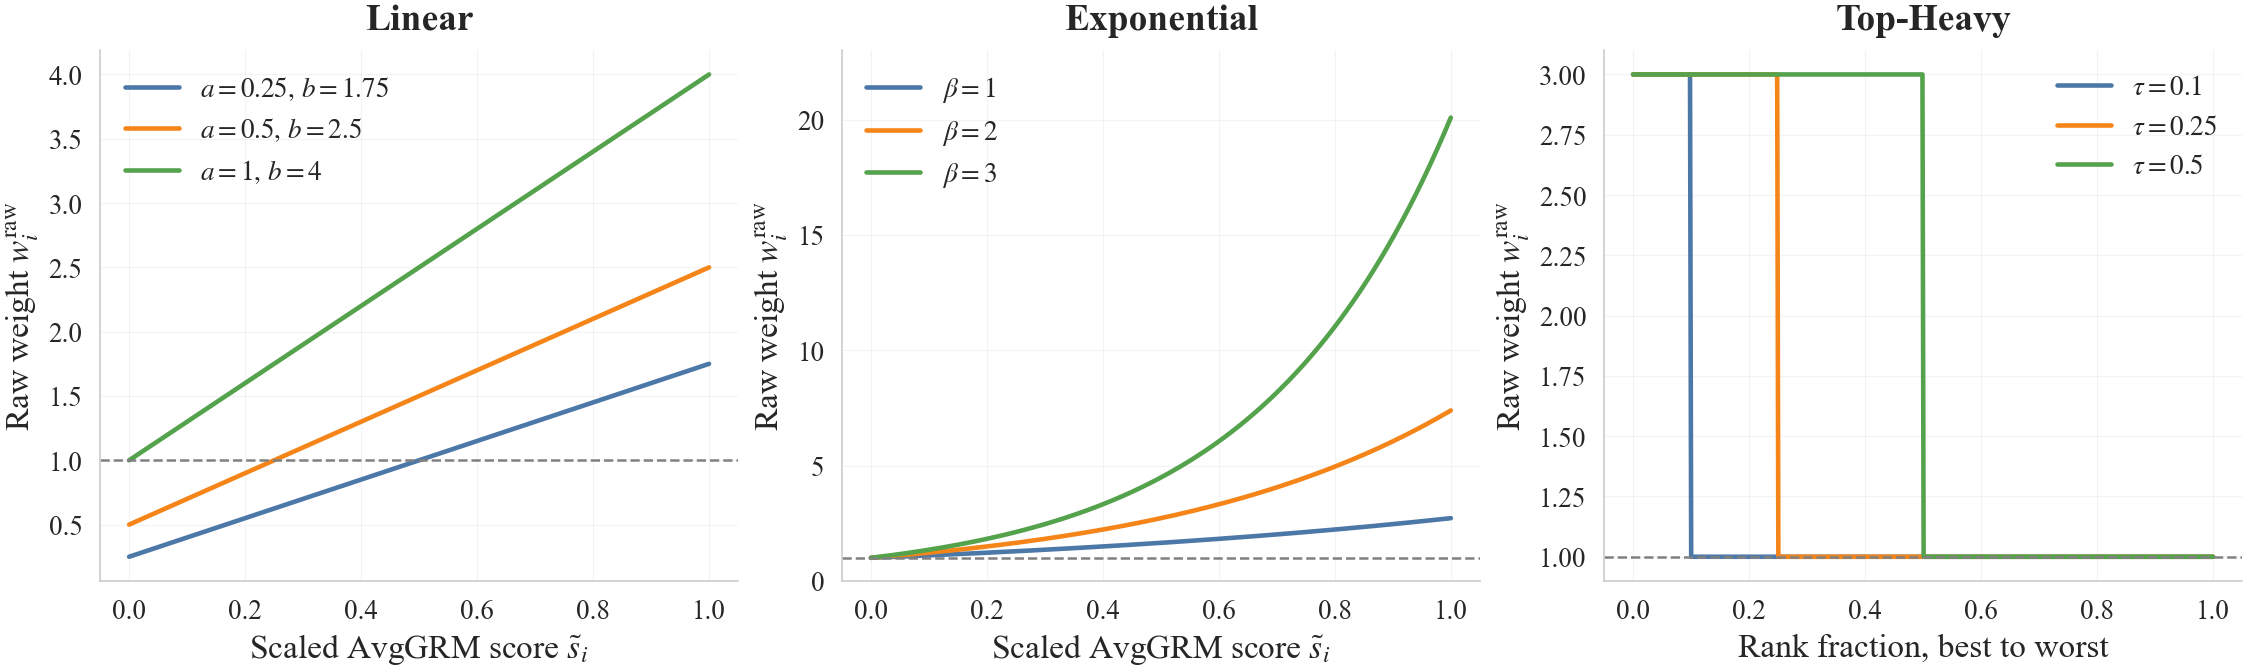

In [25]:
def plot_weighting_schemes(output_dir=FIGURES_DIR):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    colors = ["#4C78A8", "#F58518", "#54A24B"]
    score = np.linspace(0.0, 1.0, 500)
    rank_frac = np.linspace(0.0, 1.0, 500)

    title_size = 18
    label_size = 16
    legend_size = 13
    tick_size = 13
    fig, axes = plt.subplots(1, 3, figsize=(15.0, 4.5), constrained_layout=True)

    ax = axes[0]
    linear_params = [(0.25, 1.75), (0.50, 2.50), (1.00, 4.00)]
    for color, (a, b) in zip(colors, linear_params):
        ax.plot(score, a + (b - a) * score, color=color, lw=2.2, label=fr"$a={a:g},\, b={b:g}$")
    ax.axhline(1.0, color="0.5", lw=1.2, ls="--")
    ax.set_title("Linear", fontsize=title_size, pad=10)
    ax.set_xlabel(r"Scaled AvgGRM score $\tilde{s}_i$", fontsize=label_size)
    ax.set_ylabel(r"Raw weight $w_i^{\mathrm{raw}}$", fontsize=label_size)
    ax.legend(frameon=False, fontsize=legend_size)
    style_axes(ax)

    ax = axes[1]
    exp_betas = [1.0, 2.0, 3.0]
    for color, beta in zip(colors, exp_betas):
        ax.plot(score, np.exp(beta * score), color=color, lw=2.2, label=fr"$\beta={beta:g}$")
    ax.axhline(1.0, color="0.5", lw=1.2, ls="--")
    ax.set_ylim(0, 23)
    ax.set_title("Exponential", fontsize=title_size, pad=10)
    ax.set_xlabel(r"Scaled AvgGRM score $\tilde{s}_i$", fontsize=label_size)
    ax.set_ylabel(r"Raw weight $w_i^{\mathrm{raw}}$", fontsize=label_size)
    ax.legend(frameon=False, fontsize=legend_size)
    style_axes(ax)

    ax = axes[2]
    top_fracs = [0.10, 0.25, 0.50]
    low = 1.0
    high = 3.0
    for color, tau in zip(colors, top_fracs):
        weights = np.where(rank_frac <= tau, high, low)
        ax.plot(rank_frac, weights, color=color, lw=2.2, label=fr"$\tau={tau:g}$")
    ax.axhline(1.0, color="0.5", lw=1.2, ls="--")
    ax.set_title("Top-Heavy", fontsize=title_size, pad=10)
    ax.set_xlabel("Rank fraction, best to worst", fontsize=label_size)
    ax.set_ylabel(r"Raw weight $w_i^{\mathrm{raw}}$", fontsize=label_size)
    ax.legend(frameon=False, fontsize=legend_size)
    style_axes(ax)

    for ax in axes.flat:
        ax.tick_params(labelsize=tick_size)

    pdf_path = output_dir / "weighting_schemes.pdf"
    png_path = output_dir / "weighting_schemes.png"
    pdf_path = save_figure(fig, pdf_path, bbox_inches="tight")
    png_path = save_figure(fig, png_path, bbox_inches="tight")
    return fig, (pdf_path, png_path)


fig, weighting_paths = plot_weighting_schemes()
weighting_paths


## Results

### SNP PCA by island


(WindowsPath('c:/Users/Simen/OneDrive - NTNU/FYSMAT/INDMAT/MASTER/69c525a2d91967a989023aaf/Images/pca_island_pairwise_3x1.pdf'),
 WindowsPath('c:/Users/Simen/OneDrive - NTNU/FYSMAT/INDMAT/MASTER/69c525a2d91967a989023aaf/Images/pca_island_pairwise_3x1.png'))

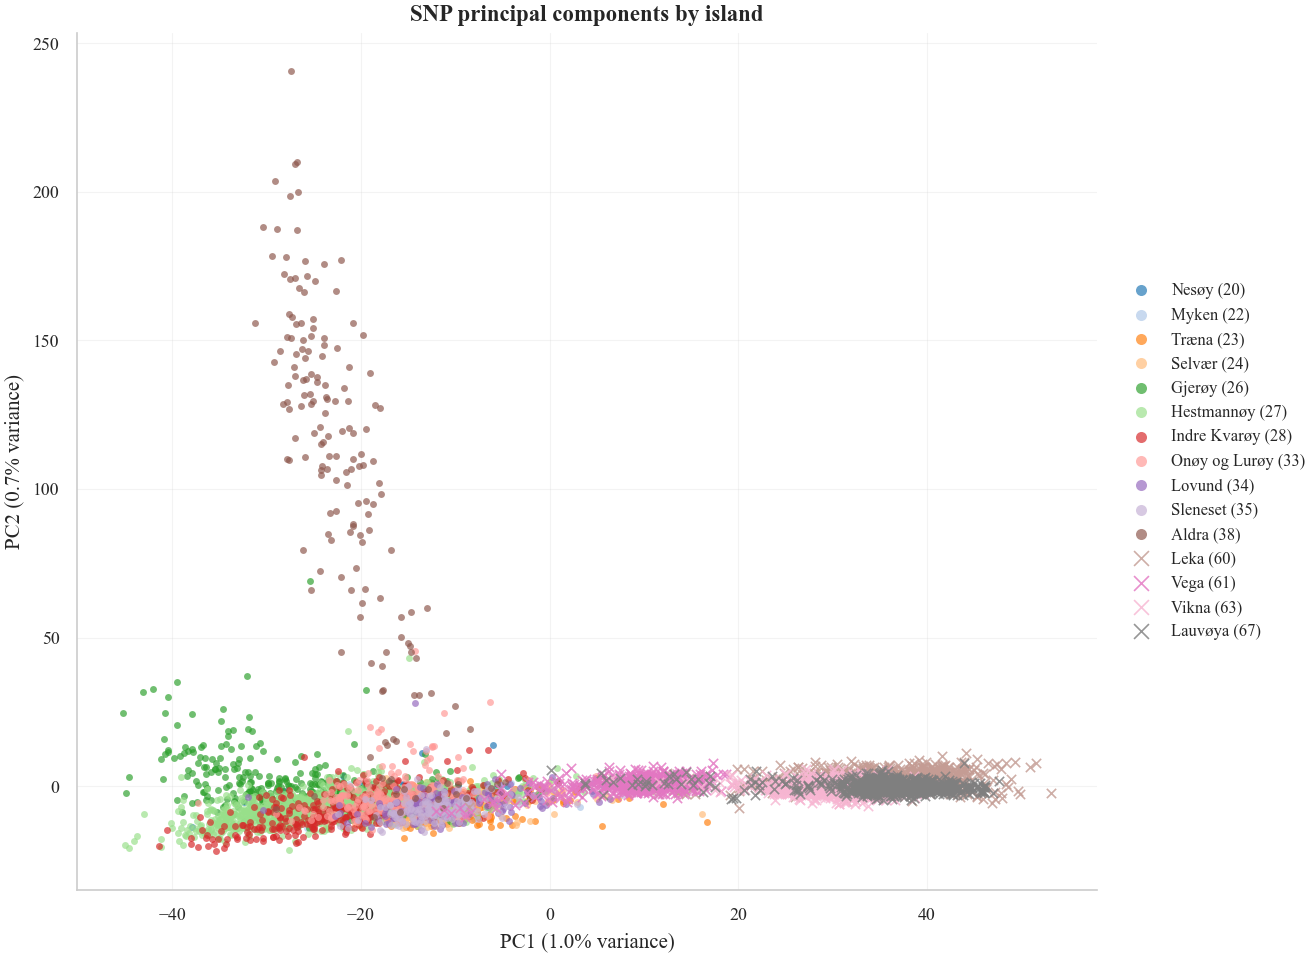

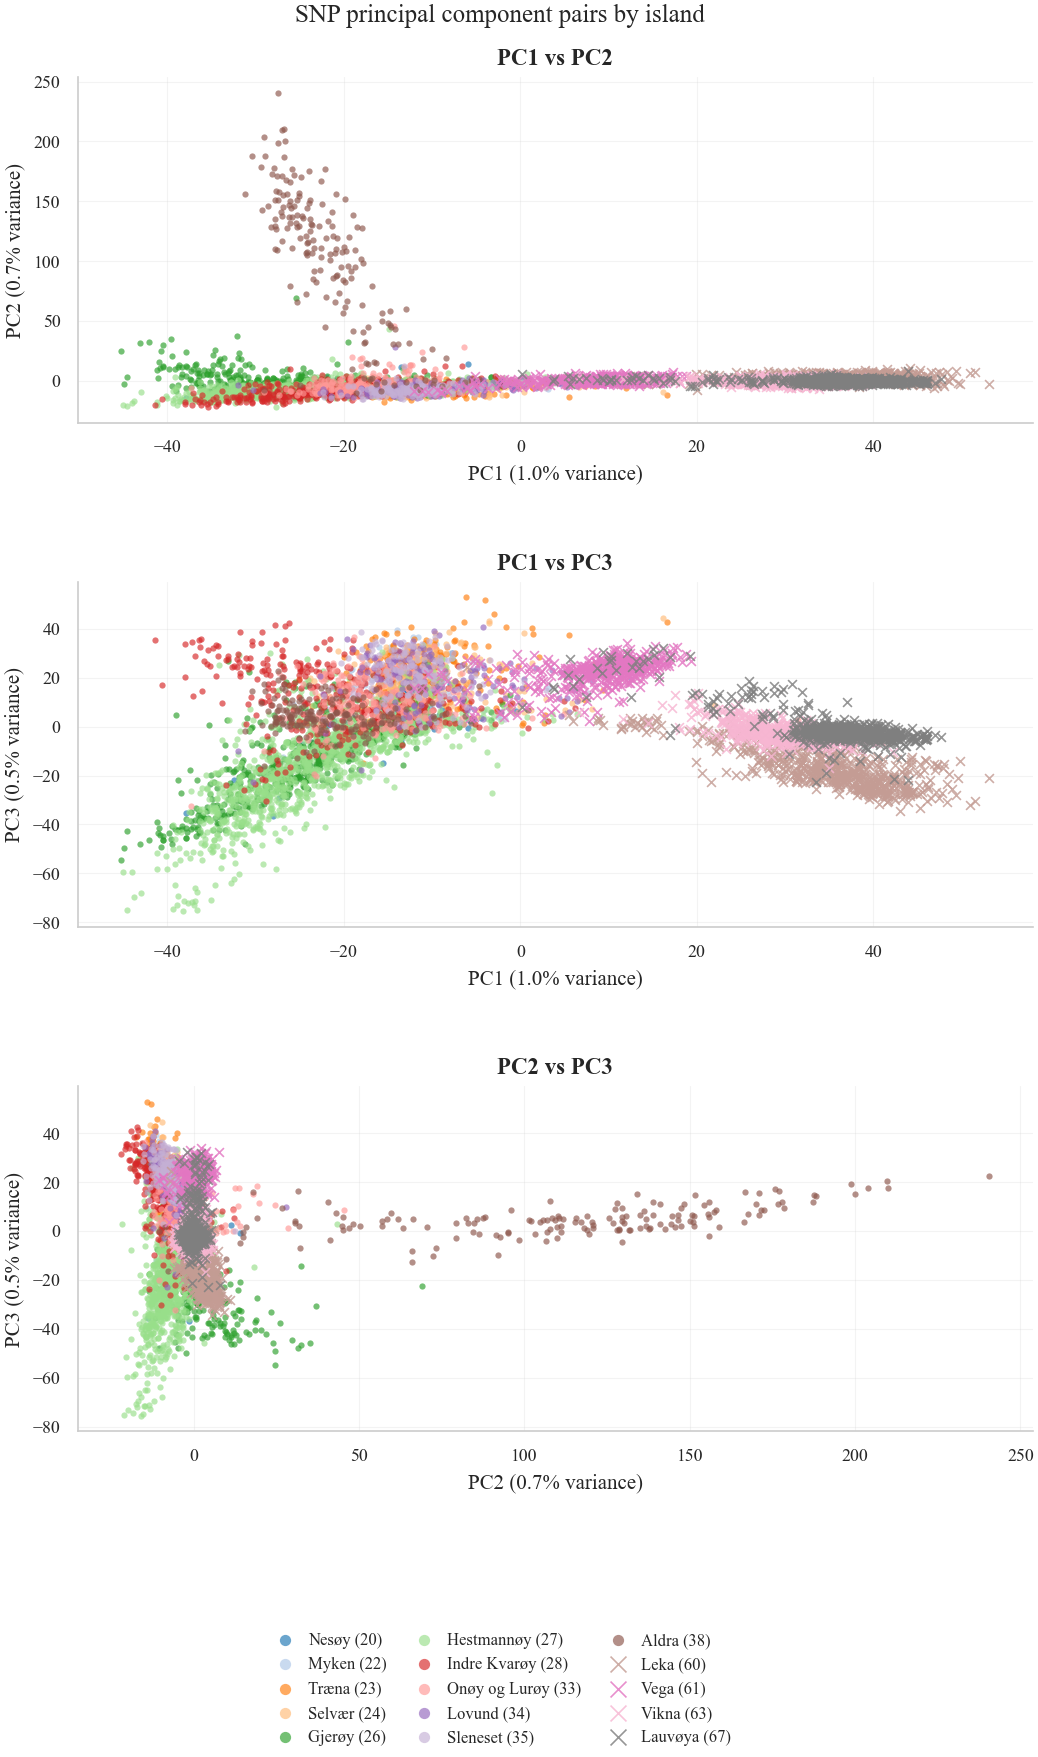

In [26]:
def load_snp_data_for_pca(npz_path=DATA_DIR / "npz" / "snp_body_mass_ALL.npz", min_count=20):
    data = np.load(npz_path, allow_pickle=False)
    X = data["snp"].astype(np.float32, copy=True)
    ids = data["ids"].astype(str)
    locality = data["locality"].astype(str)

    locality = np.where(locality == "68", "67", locality)
    counts = pd.Series(locality).value_counts()
    keep = counts[counts >= min_count].index.to_numpy()
    mask = np.isin(locality, keep)

    return X[mask], ids[mask], locality[mask]


def compute_snp_pca(X, n_components=2, standardize=True, max_snps=None, random_state=14):
    rng = np.random.default_rng(random_state)
    if max_snps is not None and max_snps < X.shape[1]:
        cols = np.sort(rng.choice(X.shape[1], size=int(max_snps), replace=False))
        X = X[:, cols]

    mean = X.mean(axis=0, dtype=np.float64).astype(np.float32)
    X = X - mean

    if standardize:
        std = X.std(axis=0, dtype=np.float64).astype(np.float32)
        std[std == 0] = 1.0
        X = X / std

    pca = PCA(n_components=n_components, svd_solver="randomized", random_state=random_state)
    scores = pca.fit_transform(X)
    return scores, pca.explained_variance_ratio_


def plot_pca_by_island(
    npz_path=DATA_DIR / "npz" / "snp_body_mass_ALL.npz",
    output_dir=IMAGES_DIR,
    min_count=20,
    max_snps=None,
    random_state=14,
):
    X, ids, locality = load_snp_data_for_pca(npz_path=npz_path, min_count=min_count)
    scores, variance_ratio = compute_snp_pca(
        X,
        n_components=2,
        standardize=True,
        max_snps=max_snps,
        random_state=random_state,
    )

    df = pd.DataFrame(
        {
            "ringnr": ids,
            "PC1": scores[:, 0],
            "PC2": scores[:, 1],
            "island_id": locality,
        }
    )
    df["island"] = df["island_id"].map(ISLAND_ID_TO_NAME).fillna(df["island_id"])

    order = numeric_sort(df["island_id"].unique())
    colors = sns.color_palette("tab20", n_colors=len(order))

    fig, ax = plt.subplots(figsize=(8.8, 6.4), constrained_layout=True)
    for idx, island_id in enumerate(order):
        sub = df[df["island_id"] == island_id]
        label = f"{ISLAND_ID_TO_NAME.get(island_id, island_id)} ({island_id})"
        is_southern = island_id in SOUTHERN_ISLAND_IDS
        ax.scatter(
            sub["PC1"],
            sub["PC2"],
            s=20 if is_southern else 11,
            alpha=0.82 if is_southern else 0.68,
            linewidths=0.8 if is_southern else 0,
            color=colors[idx],
            marker="x" if is_southern else "o",
            label=label,
        )

    ax.set_xlabel(f"PC1 ({variance_ratio[0] * 100:.1f}% variance)")
    ax.set_ylabel(f"PC2 ({variance_ratio[1] * 100:.1f}% variance)")
    ax.set_title("SNP principal components by island")
    style_axes(ax)
    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        ncol=1,
        markerscale=1.6,
        borderaxespad=0.0,
    )

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    pdf_path = output_dir / "pca_island_pc1_pc2.pdf"
    png_path = output_dir / "pca_island_pc1_pc2.png"
    pdf_path = save_figure(fig, pdf_path, bbox_inches="tight")
    png_path = save_figure(fig, png_path, bbox_inches="tight")
    return fig, df, variance_ratio, (pdf_path, png_path)


fig, pca_scores, pca_variance_ratio, pca_paths = plot_pca_by_island()
pca_paths


def plot_pca_pairwise_by_island(
    npz_path=DATA_DIR / "npz" / "snp_body_mass_ALL.npz",
    output_dir=IMAGES_DIR,
    min_count=20,
    max_snps=None,
    random_state=14,
):
    X, ids, locality = load_snp_data_for_pca(npz_path=npz_path, min_count=min_count)
    scores, variance_ratio = compute_snp_pca(
        X,
        n_components=3,
        standardize=True,
        max_snps=max_snps,
        random_state=random_state,
    )

    df = pd.DataFrame(
        {
            "ringnr": ids,
            "PC1": scores[:, 0],
            "PC2": scores[:, 1],
            "PC3": scores[:, 2],
            "island_id": locality,
        }
    )
    df["island"] = df["island_id"].map(ISLAND_ID_TO_NAME).fillna(df["island_id"])

    order = numeric_sort(df["island_id"].unique())
    colors = sns.color_palette("tab20", n_colors=len(order))
    pairs = [("PC1", "PC2"), ("PC1", "PC3"), ("PC2", "PC3")]

    fig, axes = plt.subplots(3, 1, figsize=(7.4, 12.2), constrained_layout=False)
    handles = []
    labels = []

    for ax, (x_col, y_col) in zip(axes, pairs):
        for idx, island_id in enumerate(order):
            sub = df[df["island_id"] == island_id]
            label = f"{ISLAND_ID_TO_NAME.get(island_id, island_id)} ({island_id})"
            is_southern = island_id in SOUTHERN_ISLAND_IDS
            scatter = ax.scatter(
                sub[x_col],
                sub[y_col],
                s=18 if is_southern else 9,
                alpha=0.82 if is_southern else 0.66,
                linewidths=0.8 if is_southern else 0,
                color=colors[idx],
                marker="x" if is_southern else "o",
                label=label,
            )
            if ax is axes[0]:
                handles.append(scatter)
                labels.append(label)

        x_idx = int(x_col[-1]) - 1
        y_idx = int(y_col[-1]) - 1
        ax.set_xlabel(f"{x_col} ({variance_ratio[x_idx] * 100:.1f}% variance)")
        ax.set_ylabel(f"{y_col} ({variance_ratio[y_idx] * 100:.1f}% variance)")
        ax.set_title(f"{x_col} vs {y_col}")
        style_axes(ax)

    fig.suptitle("SNP principal component pairs by island", y=0.98)
    fig.legend(
        handles,
        labels,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.02),
        frameon=False,
        ncol=3,
        markerscale=1.8,
        columnspacing=1.2,
        handletextpad=0.4,
    )
    fig.subplots_adjust(left=0.12, right=0.98, top=0.94, bottom=0.20, hspace=0.46)

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    pdf_path = output_dir / "pca_island_pairwise_3x1.pdf"
    png_path = output_dir / "pca_island_pairwise_3x1.png"
    pdf_path = save_figure(fig, pdf_path, bbox_inches="tight")
    png_path = save_figure(fig, png_path, bbox_inches="tight")
    return fig, df, variance_ratio, (pdf_path, png_path)


fig, pca_pairwise_scores, pca_pairwise_variance_ratio, pca_pairwise_paths = plot_pca_pairwise_by_island()
pca_pairwise_paths



### Across-population performance

Per-island Pearson r for the across-population prediction baselines and the BPCRR direct LOIO run. Ridge baselines come from `outputs/final_results/ridge_across_pop_alpha1e5/`; BPCRR comes from the full-source BPCRR output directory. The 20k SNP ridge baseline is averaged across SNP-repeat seeds within each target island before plotting; the other methods have one value per target island.


In [27]:
import json

FINAL_RESULTS_DIR = REPO_ROOT / "outputs" / "final_results"
RIDGE_ACROSS_POP_DIR = FINAL_RESULTS_DIR / "ridge_across_pop_alpha1e5"
RIDGE_ACROSS_POP_STEM = "ridge_across_pop_alpha1e5"
BPCRR_FULL_SOURCE_DIR = FINAL_RESULTS_DIR / "bpcrr_inla_full_source_1000pc"
BPCRR_FULL_SOURCE_STEM = "bpcrr_inla_rank_select"
BPCRR_LOIO_V2_DIR = FINAL_RESULTS_DIR / "bpcrr_inla_loio_v2"
BPCRR_LOIO_V2_STEM = "bpcrr_inla_rank_select"
BPCRR_LOIO_V3_DIR = FINAL_RESULTS_DIR / "bpcrr_inla_loio_v3"
BPCRR_LOIO_V3_STEM = "bpcrr_inla_rank_select"
E1_NESTED_L10_DIR = FINAL_RESULTS_DIR / "e1_pc_ridge_nested_loio_10"
E1_NESTED_L10_STEM = "e1_pc_ridge_nested_loio_10"
E1_FIXED_L10_DIR = FINAL_RESULTS_DIR / "e1_pc_ridge_fixed_loio_l10"
E1_FIXED_L10_STEM = "e1_pc_ridge_fixed_loio_l10"

TRAIT_LABELS = {
    "body_mass": "Body mass",
    "thr_tarsus": "Tarsus length",
    "thr_wing": "Wing length",
}

ACROSS_POP_METHOD_LABELS = {
    "all_snps": "Ridge, all SNPs",
    "pcs_1000": "Ridge, 1000 PCs",
    "e1_pc_ridge_fixed_l10": "PC Ridge, tuned",
    "bpcrr_full_source_1000pc": "BPCRR",
    "bpcrr_inla_loio_v2": "BPCRR v2",
    "bpcrr_inla_loio_v3": "BPCRR v3",
}
ACROSS_POP_METHOD_ORDER = [
    "Ridge, all SNPs",
    "Ridge, 1000 PCs",
    "PC Ridge, tuned",
    "BPCRR",
    "BPCRR v2",
    "BPCRR v3",
]

# Backwards-compatible aliases (old names used elsewhere in the notebook).
RIDGE_METHOD_LABELS = ACROSS_POP_METHOD_LABELS
RIDGE_METHOD_ORDER = ACROSS_POP_METHOD_ORDER


def load_ridge_across_pop_results(
    results_dir=RIDGE_ACROSS_POP_DIR,
    file_stem=RIDGE_ACROSS_POP_STEM,
):
    results_dir = Path(results_dir)
    csv_path = results_dir / f"{file_stem}_per_fold_results.csv"
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        df["source_file"] = str(csv_path.relative_to(REPO_ROOT))
        return df

    rows = []
    for json_path in sorted(results_dir.rglob(f"{file_stem}_results.json")):
        try:
            with open(json_path, "r", encoding="utf-8") as f:
                payload = json.load(f)
        except json.JSONDecodeError:
            print(f"Skipping partially written JSON: {json_path.relative_to(REPO_ROOT)}")
            continue

        rel_parts = json_path.relative_to(results_dir).parts
        config_used = payload.get("config_used", {})
        trait = rel_parts[0] if rel_parts else config_used.get("trait")
        snp_experiment = config_used.get("snp_experiment")
        if snp_experiment is None and len(rel_parts) >= 3:
            snp_experiment = rel_parts[2]

        snp_repeat = config_used.get("snp_repeat")
        repeat_name = json_path.parent.name
        if snp_repeat is None and repeat_name.startswith("repeat_"):
            snp_repeat = int(repeat_name.split("_", 1)[1])

        for fold in payload.get("per_fold", []):
            rows.append(
                {
                    "trait": trait,
                    "snp_experiment": snp_experiment,
                    "snp_repeat": snp_repeat,
                    "snp_seed": config_used.get("snp_seed"),
                    "num_snps_requested": config_used.get("num_snps_requested"),
                    "n_pcs_requested": config_used.get("n_pcs_requested"),
                    "use_pcs": config_used.get("use_pcs"),
                    "n_features_fit": config_used.get("n_features_fit"),
                    "alpha": config_used.get("alpha"),
                    "source_file": str(json_path.relative_to(REPO_ROOT)),
                    **fold,
                }
            )

    return pd.DataFrame(rows)


def load_bpcrr_results(
    results_dir=BPCRR_FULL_SOURCE_DIR,
    file_stem=BPCRR_FULL_SOURCE_STEM,
):
    """Walk per-trait BPCRR result folders and concat the per-fold CSVs."""
    results_dir = Path(results_dir)
    frames = []
    if not results_dir.exists():
        return pd.DataFrame()

    for trait_dir in sorted(p for p in results_dir.iterdir() if p.is_dir()):
        csv_path = trait_dir / f"{file_stem}_results.csv"
        if not csv_path.exists():
            continue
        df = pd.read_csv(csv_path)
        if "trait" not in df.columns:
            df["trait"] = trait_dir.name
        df["source_file"] = str(csv_path.relative_to(REPO_ROOT))
        frames.append(df)

    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


def load_bpcrr_full_source_results(
    results_dir=BPCRR_FULL_SOURCE_DIR,
    file_stem=BPCRR_FULL_SOURCE_STEM,
):
    return load_bpcrr_results(results_dir=results_dir, file_stem=file_stem)


def load_bpcrr_loio_v3_results(
    results_dir=BPCRR_LOIO_V3_DIR,
    file_stem=BPCRR_LOIO_V3_STEM,
):
    return load_bpcrr_results(results_dir=results_dir, file_stem=file_stem)


def load_bpcrr_loio_v2_results(
    results_dir=BPCRR_LOIO_V2_DIR,
    file_stem=BPCRR_LOIO_V2_STEM,
):
    return load_bpcrr_results(results_dir=results_dir, file_stem=file_stem)


def _load_pc_ridge_loio_per_fold(results_dir, file_stem):
    """Concat per-trait CSVs from <results_dir>/<trait>/<stem>_per_fold_results.csv.

    Avoids relying on the top-level combined CSV, which is overwritten when the
    runner is invoked per-trait.
    """
    results_dir = Path(results_dir)
    if not results_dir.exists():
        return pd.DataFrame()
    frames = []
    for trait_dir in sorted(p for p in results_dir.iterdir() if p.is_dir()):
        csv_path = trait_dir / f"{file_stem}_per_fold_results.csv"
        if not csv_path.exists():
            continue
        df = pd.read_csv(csv_path)
        if "trait" not in df.columns or df["trait"].isna().all():
            df["trait"] = trait_dir.name
        df["source_file"] = str(csv_path.relative_to(REPO_ROOT))
        frames.append(df)
    if frames:
        return pd.concat(frames, ignore_index=True)

    # Fallback: top-level combined file (used when only one trait was run).
    csv_path = results_dir / f"{file_stem}_per_fold_results.csv"
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        df["source_file"] = str(csv_path.relative_to(REPO_ROOT))
        return df
    return pd.DataFrame()


def load_e1_nested_l10_per_fold(results_dir=E1_NESTED_L10_DIR, file_stem=E1_NESTED_L10_STEM):
    return _load_pc_ridge_loio_per_fold(results_dir, file_stem)


def load_e1_fixed_l10_per_fold(results_dir=E1_FIXED_L10_DIR, file_stem=E1_FIXED_L10_STEM):
    return _load_pc_ridge_loio_per_fold(results_dir, file_stem)


def _pc_ridge_rows_to_box_pieces(df, snp_experiment_key, columns):
    if df is None or df.empty:
        return None
    edf = df.copy()
    if "test_island_original_label" not in edf.columns:
        edf["test_island_original_label"] = pd.NA
    original_label = edf["test_island_original_label"].astype("string")
    code_label = edf["test_island_code"].astype("string")
    edf["target_island_key"] = original_label.fillna(code_label)
    edf["target_island"] = edf["test_island"].fillna(edf["target_island_key"])
    edf["snp_experiment"] = snp_experiment_key
    edf["method"] = ACROSS_POP_METHOD_LABELS[snp_experiment_key]
    edf["trait_label"] = edf["trait"].map(TRAIT_LABELS).fillna(edf["trait"])
    edf["n_repeats_available"] = 1
    return edf[columns]


def prepare_across_pop_boxplot_df(
    ridge_df,
    bpcrr_df,
    bpcrr_v2_df=None,
    bpcrr_v3_df=None,
    e1_nested_l10_df=None,
    e1_fixed_l10_df=None,
    bpcrr_analysis="full_baseline",
):
    """Combine ridge, BPCRR and tuned PC-ridge results into one row per trait, method, and island."""
    columns = [
        "trait",
        "trait_label",
        "snp_experiment",
        "method",
        "target_island_key",
        "target_island",
        "test_island_code",
        "pearson_r",
        "n_repeats_available",
    ]

    pieces = []

    # ---- Ridge baselines ----
    if not ridge_df.empty:
        df = ridge_df[ridge_df["snp_experiment"].isin(ACROSS_POP_METHOD_LABELS)].copy()
        if not df.empty:
            if "test_island_original_label" not in df.columns:
                df["test_island_original_label"] = pd.NA

            original_label = df["test_island_original_label"].astype("string")
            code_label = df["test_island_code"].astype("string")
            df["target_island_key"] = original_label.fillna(code_label)
            df["target_island"] = df["test_island"].fillna(df["target_island_key"])

            grouped = (
                df.groupby(
                    [
                        "trait",
                        "snp_experiment",
                        "target_island_key",
                        "target_island",
                        "test_island_code",
                    ],
                    as_index=False,
                    dropna=False,
                )
                .agg(
                    pearson_r=("pearson_r", "mean"),
                    n_repeats_available=("snp_repeat", "nunique"),
                )
            )
            grouped["method"] = grouped["snp_experiment"].map(ACROSS_POP_METHOD_LABELS)
            grouped["trait_label"] = grouped["trait"].map(TRAIT_LABELS).fillna(grouped["trait"])
            pieces.append(grouped[columns])

    # ---- BPCRR baselines ----
    for bdf_source, snp_experiment_key in [
        (bpcrr_df, "bpcrr_full_source_1000pc"),
        (bpcrr_v2_df, "bpcrr_inla_loio_v2"),
        (bpcrr_v3_df, "bpcrr_inla_loio_v3"),
    ]:
        if bdf_source is None or bdf_source.empty:
            continue

        bdf = bdf_source[bdf_source["analysis"] == bpcrr_analysis].copy()
        if not bdf.empty:
            bdf = (
                bdf.groupby(
                    ["trait", "target_island", "target_island_name"],
                    as_index=False,
                    dropna=False,
                )
                .agg(
                    pearson_r=("corr_eval", "mean"),
                    n_repeats_available=("repeat", "nunique"),
                )
            )
            bdf["snp_experiment"] = snp_experiment_key
            bdf["method"] = ACROSS_POP_METHOD_LABELS[snp_experiment_key]
            bdf["trait_label"] = bdf["trait"].map(TRAIT_LABELS).fillna(bdf["trait"])
            bdf = bdf.rename(
                columns={
                    "target_island": "test_island_code",
                    "target_island_name": "target_island",
                }
            )
            bdf["target_island_key"] = bdf["test_island_code"].astype("string")
            pieces.append(bdf[columns])

    # ---- Tuned PC-ridge l=10 comparison ----
    piece = _pc_ridge_rows_to_box_pieces(e1_fixed_l10_df, "e1_pc_ridge_fixed_l10", columns)
    if piece is not None:
        pieces.append(piece)

    if not pieces:
        return pd.DataFrame(columns=columns)

    out = pd.concat(pieces, ignore_index=True)
    return out.sort_values(["trait", "method", "test_island_code"]).reset_index(drop=True)


# Keep the old name as an alias for any downstream consumers.
def prepare_ridge_across_pop_boxplot_df(ridge_df):
    return prepare_across_pop_boxplot_df(ridge_df, pd.DataFrame())


ridge_across_pop_raw = load_ridge_across_pop_results()
bpcrr_full_source_raw = load_bpcrr_full_source_results()
bpcrr_loio_v2_raw = load_bpcrr_loio_v2_results()
bpcrr_loio_v3_raw = load_bpcrr_loio_v3_results()
e1_nested_l10_raw = load_e1_nested_l10_per_fold()
e1_fixed_l10_raw = load_e1_fixed_l10_per_fold()
across_pop_box_df = prepare_across_pop_boxplot_df(
    ridge_across_pop_raw,
    bpcrr_full_source_raw,
    bpcrr_v2_df=bpcrr_loio_v2_raw,
    bpcrr_v3_df=bpcrr_loio_v3_raw,
    e1_nested_l10_df=e1_nested_l10_raw,
    e1_fixed_l10_df=e1_fixed_l10_raw,
)
ridge_across_pop_box_df = across_pop_box_df  # alias for backwards compatibility

print(
    f"Loaded {len(ridge_across_pop_raw)} ridge per-fold rows, "
    f"{len(bpcrr_full_source_raw)} BPCRR per-fold rows, "
    f"{len(bpcrr_loio_v2_raw)} BPCRR v2 per-fold rows, "
    f"{len(bpcrr_loio_v3_raw)} BPCRR v3 per-fold rows, "
    f"{len(e1_fixed_l10_raw)} PC Ridge tuned rows"
)
across_pop_box_df.groupby(["trait", "method"], dropna=False).size()


Loaded 270 ridge per-fold rows, 40 BPCRR per-fold rows, 45 BPCRR v2 per-fold rows, 45 BPCRR v3 per-fold rows, 45 PC Ridge tuned rows


trait       method         
body_mass   BPCRR              15
            BPCRR v2           15
            BPCRR v3           15
            PC Ridge, tuned    15
            Ridge, all SNPs    15
thr_tarsus  BPCRR              11
            BPCRR v2           15
            BPCRR v3           15
            PC Ridge, tuned    15
            Ridge, all SNPs    15
thr_wing    BPCRR              14
            BPCRR v2           15
            BPCRR v3           15
            PC Ridge, tuned    15
            Ridge, all SNPs    15
dtype: int64

{'body_mass': (WindowsPath('c:/Users/Simen/OneDrive - NTNU/FYSMAT/INDMAT/MASTER/69c525a2d91967a989023aaf/Figures/across_pop_prediction_boxplot_body_mass.pdf'),
  WindowsPath('c:/Users/Simen/OneDrive - NTNU/FYSMAT/INDMAT/MASTER/69c525a2d91967a989023aaf/Figures/across_pop_prediction_boxplot_body_mass.png')),
 'thr_tarsus': (WindowsPath('c:/Users/Simen/OneDrive - NTNU/FYSMAT/INDMAT/MASTER/69c525a2d91967a989023aaf/Figures/across_pop_prediction_boxplot_thr_tarsus.pdf'),
  WindowsPath('c:/Users/Simen/OneDrive - NTNU/FYSMAT/INDMAT/MASTER/69c525a2d91967a989023aaf/Figures/across_pop_prediction_boxplot_thr_tarsus.png')),
 'thr_wing': (WindowsPath('c:/Users/Simen/OneDrive - NTNU/FYSMAT/INDMAT/MASTER/69c525a2d91967a989023aaf/Figures/across_pop_prediction_boxplot_thr_wing.pdf'),
  WindowsPath('c:/Users/Simen/OneDrive - NTNU/FYSMAT/INDMAT/MASTER/69c525a2d91967a989023aaf/Figures/across_pop_prediction_boxplot_thr_wing.png'))}

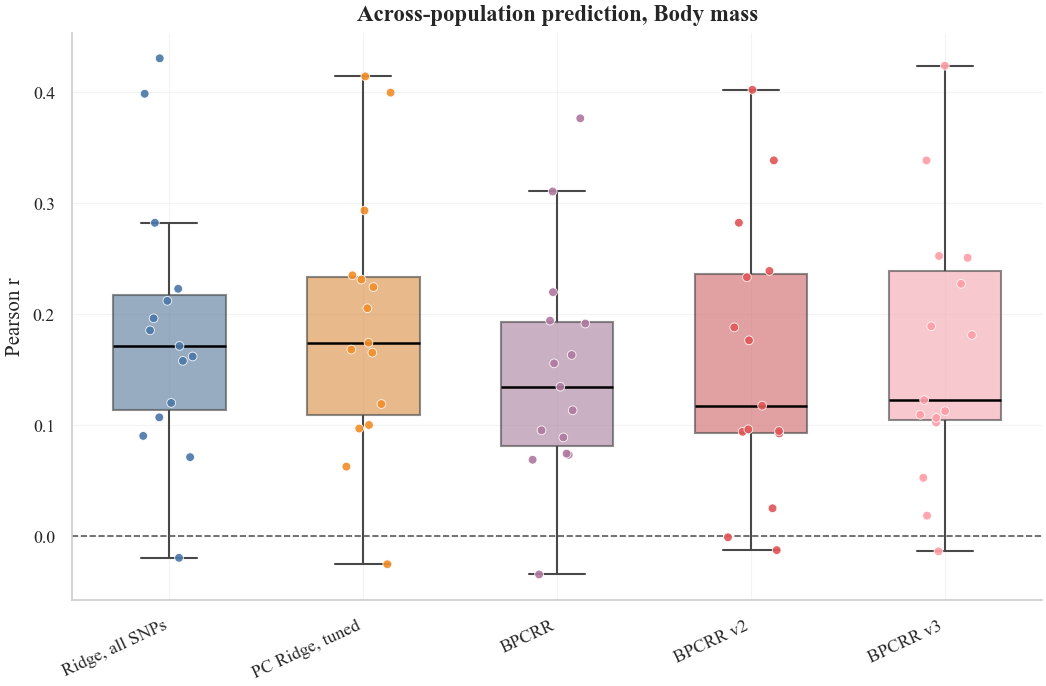

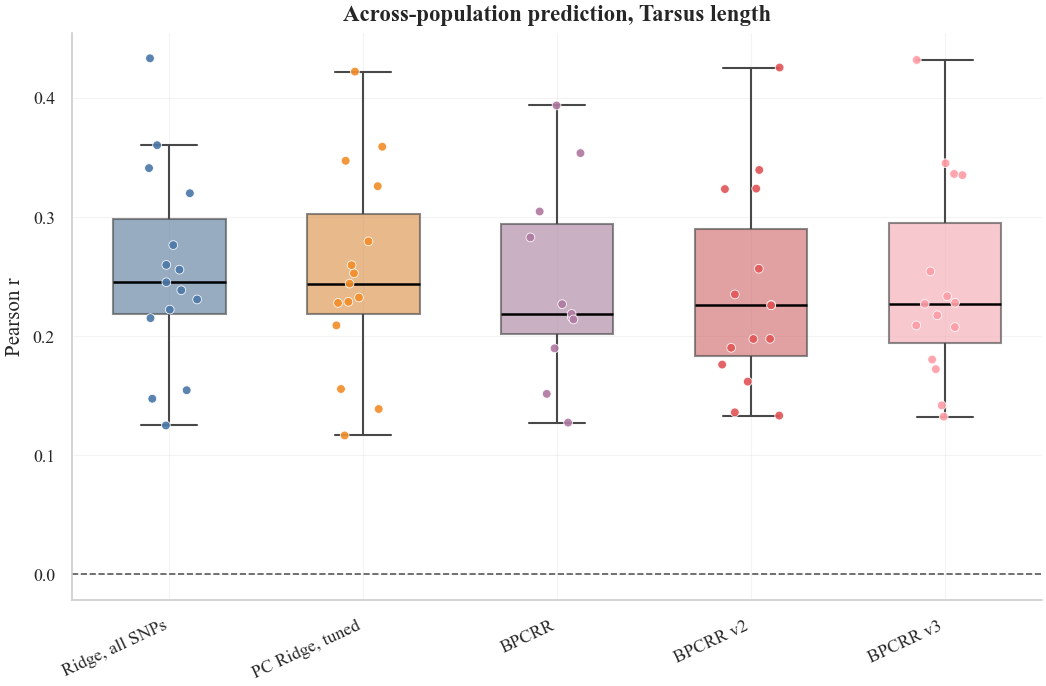

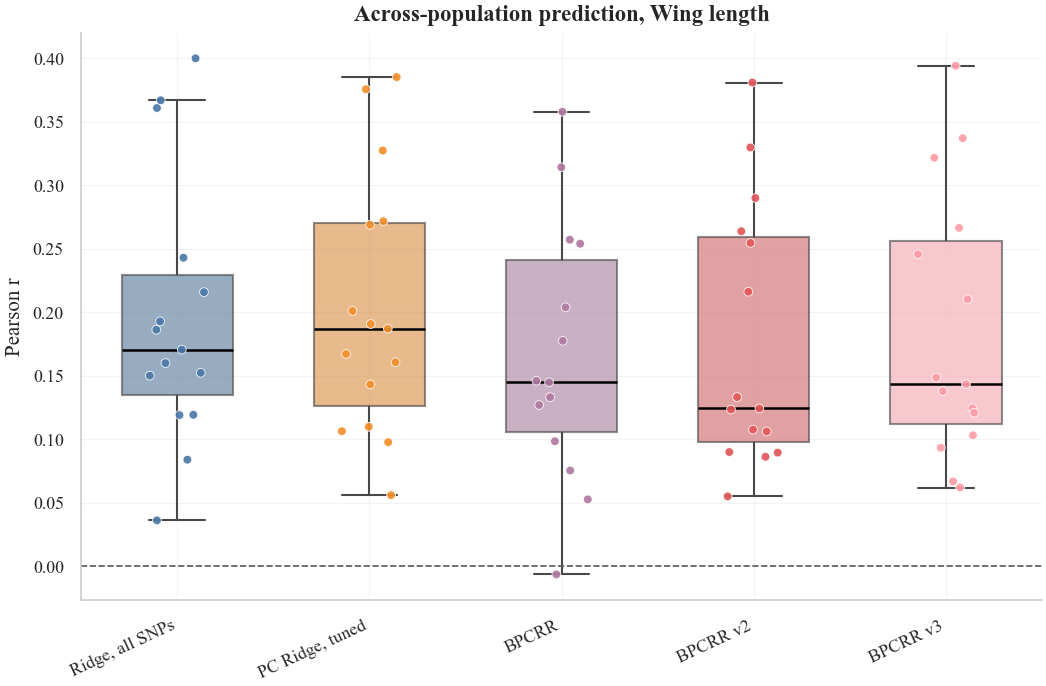

In [28]:
def plot_across_pop_prediction_boxplots_by_trait(
    box_df,
    output_dir=FIGURES_DIR,
    file_stem="across_pop_prediction_boxplot",
    method_order=None,
    trait_order=None,
):
    if box_df.empty:
        print("No across-population results found yet.")
        return {}

    method_order = list(method_order or ACROSS_POP_METHOD_ORDER)
    method_order = [m for m in method_order if m in set(box_df["method"])]
    method_order += [m for m in box_df["method"].dropna().unique() if m not in method_order]

    trait_order = list(trait_order or [t for t in TRAIT_LABELS if t in set(box_df["trait"])])
    trait_order += [t for t in box_df["trait"].dropna().unique() if t not in trait_order]

    colors = {
        "Ridge, all SNPs": "#4C78A8",
        "Ridge, 1000 PCs": "#59A14F",
        "PC Ridge, tuned": "#F28E2B",
        "BPCRR": "#B07AA1",
        "BPCRR v2": "#E15759",
        "BPCRR v3": "#FF9DA7",
    }

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    paths_by_trait = {}

    for trait in trait_order:
        sub = box_df[box_df["trait"] == trait].copy()
        if sub.empty:
            continue

        fig, ax = plt.subplots(figsize=(7.0, 4.6), constrained_layout=True)
        sns.boxplot(
            data=sub,
            x="method",
            y="pearson_r",
            order=method_order,
            hue="method",
            hue_order=method_order,
            palette=colors,
            dodge=False,
            width=0.58,
            linewidth=1.0,
            fliersize=0,
            legend=False,
            ax=ax,
            boxprops={"alpha": 0.62},
            medianprops={"color": "black", "linewidth": 1.2},
        )
        sns.stripplot(
            data=sub,
            x="method",
            y="pearson_r",
            order=method_order,
            hue="method",
            hue_order=method_order,
            palette=colors,
            dodge=False,
            jitter=0.15,
            size=4.2,
            alpha=0.92,
            edgecolor="white",
            linewidth=0.4,
            legend=False,
            ax=ax,
            zorder=3,
        )

        ax.axhline(0, color="0.35", linewidth=0.8, linestyle="--")
        ax.set_title(f"Across-population prediction, {TRAIT_LABELS.get(trait, trait)}")
        ax.set_xlabel("")
        ax.set_ylabel("Pearson r")
        ax.set_xticks(range(len(method_order)))
        ax.set_xticklabels(method_order, rotation=25, ha="right")
        style_axes(ax)

        pdf_path = output_dir / f"{file_stem}_{trait}.pdf"
        png_path = output_dir / f"{file_stem}_{trait}.png"
        pdf_path = save_figure(fig, pdf_path, bbox_inches="tight")
        png_path = save_figure(fig, png_path, bbox_inches="tight")
        paths_by_trait[trait] = (pdf_path, png_path)

    return paths_by_trait


across_pop_paths = plot_across_pop_prediction_boxplots_by_trait(across_pop_box_df)
across_pop_paths


### E1: PC-ridge nested LOIO

Nested leave-one-island-out tuning of (r, lambda) per outer target island. PCs are fit on the outer-/inner-train subset only. Results are loaded per trait from `outputs/final_results/e1_pc_ridge_nested_loio/<trait>/`.


In [29]:
E1_DIR = FINAL_RESULTS_DIR / "e1_pc_ridge_nested_loio"
E1_STEM = "e1_pc_ridge_nested_loio"


def load_e1_pc_ridge_results(results_dir=E1_DIR, file_stem=E1_STEM):
    """Load per-fold results and best-params across all traits.

    Returns
    -------
    per_fold_df : DataFrame with one row per (trait, outer fold)
    best_params : dict trait -> list of per-fold best params (from JSON)
    """
    results_dir = Path(results_dir)
    fold_frames = []
    best_params = {}

    if not results_dir.exists():
        return pd.DataFrame(), best_params

    for trait_dir in sorted(p for p in results_dir.iterdir() if p.is_dir()):
        trait = trait_dir.name
        csv_path = trait_dir / f"{file_stem}_per_fold_results.csv"
        if csv_path.exists():
            df = pd.read_csv(csv_path)
            if "trait" not in df.columns:
                df["trait"] = trait
            df["source_file"] = str(csv_path.relative_to(REPO_ROOT))
            fold_frames.append(df)

        bp_path = trait_dir / f"{file_stem}_best_params.json"
        if bp_path.exists():
            with open(bp_path, "r", encoding="utf-8") as f:
                best_params[trait] = json.load(f)

    per_fold_df = pd.concat(fold_frames, ignore_index=True) if fold_frames else pd.DataFrame()
    return per_fold_df, best_params


def summarize_e1_best_params(per_fold_df):
    """Mode r and geometric-mean alpha across outer folds, per trait."""
    if per_fold_df.empty:
        return pd.DataFrame(columns=["trait", "best_n_pcs_mode", "best_alpha_geomean", "pearson_r_mean", "pearson_r_std", "n_folds"])
    rows = []
    for trait, sub in per_fold_df.groupby("trait", sort=False):
        rows.append({
            "trait": trait,
            "trait_label": TRAIT_LABELS.get(trait, trait),
            "best_n_pcs_mode": int(sub["best_n_pcs"].mode().iloc[0]),
            "best_n_pcs_median": float(sub["best_n_pcs"].median()),
            "best_alpha_geomean": float(np.exp(np.log(sub["best_alpha"]).mean())),
            "best_alpha_median": float(sub["best_alpha"].median()),
            "pearson_r_mean": float(sub["pearson_r"].mean()),
            "pearson_r_std": float(sub["pearson_r"].std()),
            "n_folds": int(sub.shape[0]),
        })
    return pd.DataFrame(rows)


e1_per_fold_df, e1_best_params = load_e1_pc_ridge_results()
e1_summary_df = summarize_e1_best_params(e1_per_fold_df)
print(f"Loaded {len(e1_per_fold_df)} E1 per-fold rows across {e1_per_fold_df['trait'].nunique() if not e1_per_fold_df.empty else 0} traits")
e1_summary_df


Loaded 0 E1 per-fold rows across 0 traits


,trait,best_n_pcs_mode,best_alpha_geomean,pearson_r_mean,pearson_r_std,n_folds


In [30]:
def plot_e1_pc_ridge_loio_by_trait(
    per_fold_df,
    output_dir=FIGURES_DIR,
    file_stem="e1_pc_ridge_nested_loio",
    trait_order=None,
):
    """One panel per trait: per-island Pearson r as a strip, with best (r, lambda) annotated."""
    if per_fold_df.empty:
        print("No E1 results yet.")
        return {}

    trait_order = list(trait_order or [t for t in TRAIT_LABELS if t in set(per_fold_df["trait"])])
    trait_order += [t for t in per_fold_df["trait"].dropna().unique() if t not in trait_order]

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    paths = {}

    for trait in trait_order:
        sub = per_fold_df[per_fold_df["trait"] == trait].copy()
        if sub.empty:
            continue
        sub = sub.sort_values("test_island")

        fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), constrained_layout=True,
                                 gridspec_kw={"width_ratios": [1.0, 1.0]})

        ax = axes[0]
        x = np.arange(len(sub))
        ax.bar(x, sub["pearson_r"].to_numpy(), color="#4C78A8", alpha=0.75, edgecolor="white")
        ax.axhline(float(sub["pearson_r"].mean()), color="0.25", lw=1.2, ls="--",
                   label=f"mean r = {sub['pearson_r'].mean():.3f}")
        ax.axhline(0, color="0.5", lw=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels(sub["test_island"].astype(str), rotation=35, ha="right")
        ax.set_ylabel("Pearson r")
        ax.set_title(f"PC-ridge nested LOIO, {TRAIT_LABELS.get(trait, trait)}")
        ax.legend(frameon=False, loc="best")
        style_axes(ax)

        ax = axes[1]
        ax.scatter(sub["best_n_pcs"], sub["best_alpha"], s=42, color="#F58518",
                   edgecolor="white", linewidth=0.6, zorder=3)
        for _, row in sub.iterrows():
            ax.annotate(str(row["test_island"]),
                        (row["best_n_pcs"], row["best_alpha"]),
                        textcoords="offset points", xytext=(4, 3), fontsize=7)
        ax.set_yscale("log")
        ax.set_xlabel("Selected r (number of PCs)")
        ax.set_ylabel(r"Selected $\lambda$ (log)")
        ax.set_title("Per-fold selected hyperparameters")
        style_axes(ax)

        pdf_path = output_dir / f"{file_stem}_{trait}.pdf"
        png_path = output_dir / f"{file_stem}_{trait}.png"
        pdf_path = save_figure(fig, pdf_path, bbox_inches="tight")
        png_path = save_figure(fig, png_path, bbox_inches="tight")
        paths[trait] = (pdf_path, png_path)

    return paths


e1_figure_paths = plot_e1_pc_ridge_loio_by_trait(e1_per_fold_df)
e1_figure_paths


No E1 results yet.


{}

### E3: PEV-mean GA vs random training-set selection (PC ridge)

Learning curves comparing GA-selected training sets (`pevmean_ga_pc_ridge`) against size-matched random baselines (`random_pc_ridge`) evaluated with a fixed PC-ridge model. Results are loaded per trait from `outputs/final_results/e3_pevmean_ga_pc_ridge/<trait>/` and `outputs/final_results/e3_random_pc_ridge/<trait>/`.

In [31]:
E3_PEV_DIR = FINAL_RESULTS_DIR / "e3_pevmean_ga_pc_ridge"
E3_PEV_STEM = "pevmean_ga_pc_ridge"
E3_RAND_DIR = FINAL_RESULTS_DIR / "e3_random_pc_ridge"
E3_RAND_STEM = "random_pc_ridge"
E4_SIM_DIR  = FINAL_RESULTS_DIR / "e4_similarity_pc_ridge"
E4_SIM_STEM = "e4_similarity_pc_ridge"

E3_METHOD_LABELS = {
    "pevmean_ga_pc_ridge":         "PEV-mean GA",
    "random_pc_ridge":             "Random",
    "avggrm_topk":                 "AvgGRM top-k",
    "pca_target_topk":             "PC-distance top-k",
    "avggrm_diversity_lam0p25":    r"AvgGRM diversity ($\lambda=0.25$)",
    "avggrm_diversity_lam0p5":     r"AvgGRM diversity ($\lambda=0.5$)",
    "avggrm_diversity_lam1":       r"AvgGRM diversity ($\lambda=1.0$)",
    "avggrm_diversity_lam2":       r"AvgGRM diversity ($\lambda=2.0$)",
}
E3_METHOD_COLORS = {
    "PEV-mean GA":                          "#E45756",
    "Random":                               "#4C78A8",
    "AvgGRM top-k":                         "#59A14F",
    "PC-distance top-k":                    "#F28E2B",
    r"AvgGRM diversity ($\lambda=0.25$)":   "#B07AA1",
    r"AvgGRM diversity ($\lambda=0.5$)":    "#76B7B2",
    r"AvgGRM diversity ($\lambda=1.0$)":    "#9C755F",
    r"AvgGRM diversity ($\lambda=2.0$)":    "#EDC948",
}


def _load_e3_results_one(results_dir, file_stem):
    """Concat per-trait *_results.csv files under results_dir/<trait>/."""
    results_dir = Path(results_dir)
    if not results_dir.exists():
        return pd.DataFrame()
    frames = []
    for trait_dir in sorted(p for p in results_dir.iterdir() if p.is_dir()):
        csv_path = trait_dir / f"{file_stem}_results.csv"
        if not csv_path.exists():
            continue
        df = pd.read_csv(csv_path)
        if "trait" not in df.columns:
            df["trait"] = trait_dir.name
        df["source_file"] = str(csv_path.relative_to(REPO_ROOT))
        frames.append(df)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


def load_e3_results():
    """Return a combined DataFrame with PEVmean GA, random, and E4 similarity results."""
    pev  = _load_e3_results_one(E3_PEV_DIR,  E3_PEV_STEM)
    rand = _load_e3_results_one(E3_RAND_DIR, E3_RAND_STEM)
    sim  = _load_e3_results_one(E4_SIM_DIR,  E4_SIM_STEM)
    frames = [df for df in (pev, rand, sim) if not df.empty]
    if not frames:
        return pd.DataFrame()
    df = pd.concat(frames, ignore_index=True)
    df["method_label"] = df["method"].map(E3_METHOD_LABELS).fillna(df["method"])
    df["trait_label"]  = df["trait"].map(TRAIT_LABELS).fillna(df["trait"])
    return df


e3_raw = load_e3_results()
print(
    f"Loaded {len(e3_raw)} E3 rows across "
    f"{e3_raw['trait'].nunique() if not e3_raw.empty else 0} traits and "
    f"{e3_raw['method'].nunique() if not e3_raw.empty else 0} methods"
)
e3_raw.groupby(["trait", "method", "n_train_size"], dropna=False).size().unstack("method") if not e3_raw.empty else None

Loaded 8505 E3 rows across 3 traits and 8 methods


method                   avggrm_diversity_lam0p25  avggrm_diversity_lam0p5  \
trait      n_train_size                                                      
body_mass  500                                 15                       15   
           1000                                15                       15   
           1500                                15                       15   
           2000                                15                       15   
           2500                                15                       15   
           3000                                15                       15   
           3500                                15                       15   
           4000                                15                       15   
           4500                                15                       15   
thr_tarsus 500                                 15                       15   
           1000                                15                       15   
           1500                                15                       15   
           2000                                15                       15   
           2500                                15                       15   
           3000                                15                       15   
           3500                                15                       15   
           4000                                15                       15   
           4500                                15                       15   
thr_wing   500                                 15                       15   
           1000                                15                       15   
           1500                                15                       15   
           2000                                15                       15   
           2500                                15                       15   
           3000                                15                       15   
           3500                                15                       15   
           4000                                15                       15   
           4500                                15                       15   

method                   avggrm_diversity_lam1  avggrm_diversity_lam2  \
trait      n_train_size                                                 
body_mass  500                              15                     15   
           1000                             15                     15   
           1500                             15                     15   
           2000                             15                     15   
           2500                             15                     15   
           3000                             15                     15   
           3500                             15                     15   
           4000                             15                     15   
           4500                             15                     15   
thr_tarsus 500                              15                     15   
           1000                             15                     15   
           1500                             15                     15   
           2000                             15                     15   
           2500                             15                     15   
           3000                             15                     15   
           3500                             15                     15   
           4000                             15                     15   
           4500                             15                     15   
thr_wing   500                              15                     15   
           1000                             15                     15   
           1500                             15                     15   
           2000                             15            

Best diversity curve for main E3 figure: AvgGRM diversity ($\lambda=1.0$)


method_label
AvgGRM diversity ($\lambda=1.0$)     0.205944
AvgGRM diversity ($\lambda=0.5$)     0.205581
AvgGRM diversity ($\lambda=0.25$)    0.205376
AvgGRM diversity ($\lambda=2.0$)     0.205047
Name: pearson_r, dtype: float64

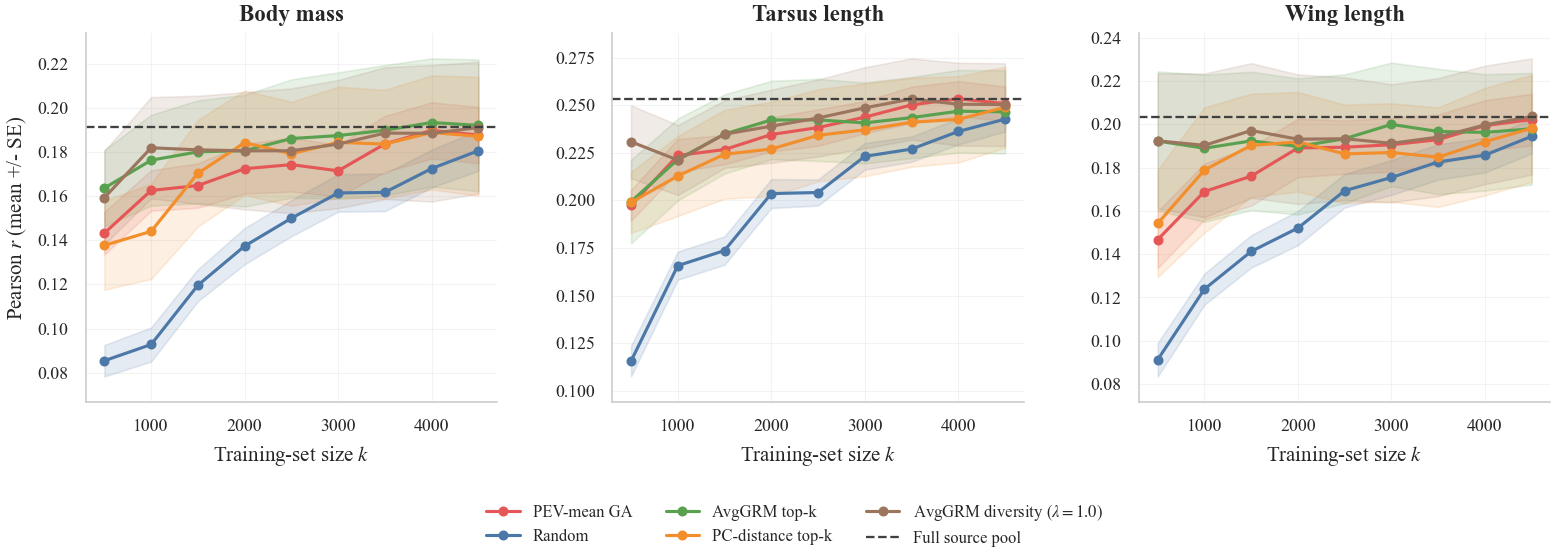

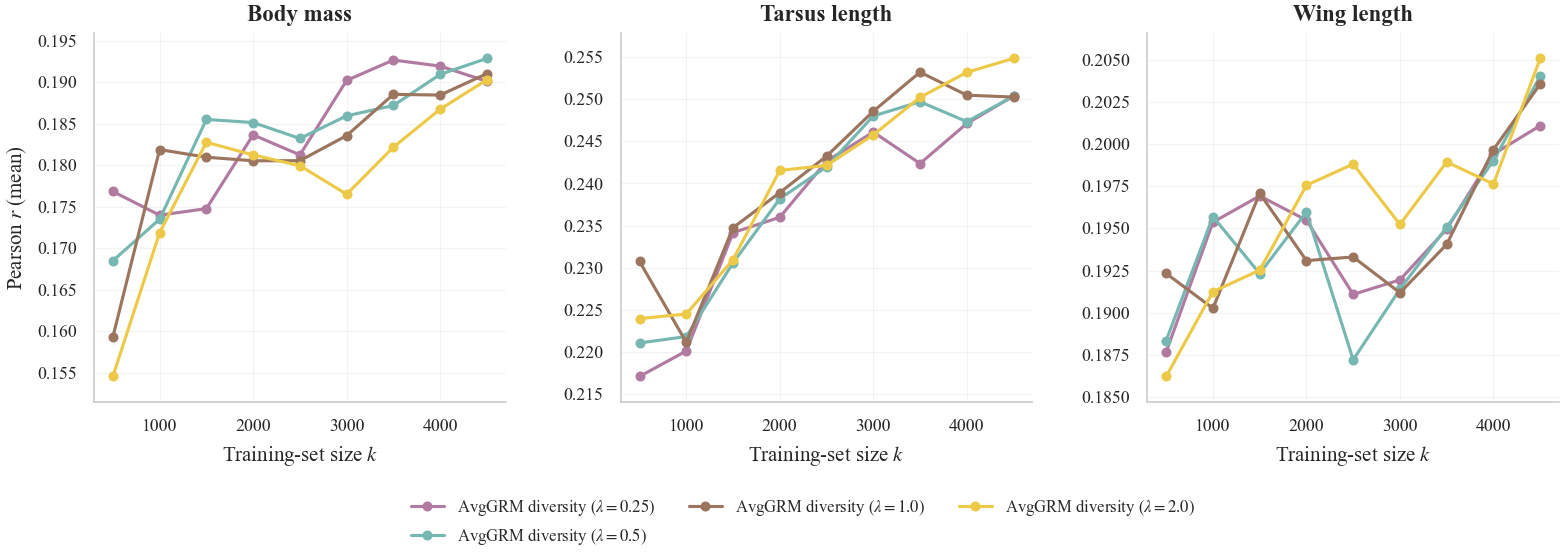

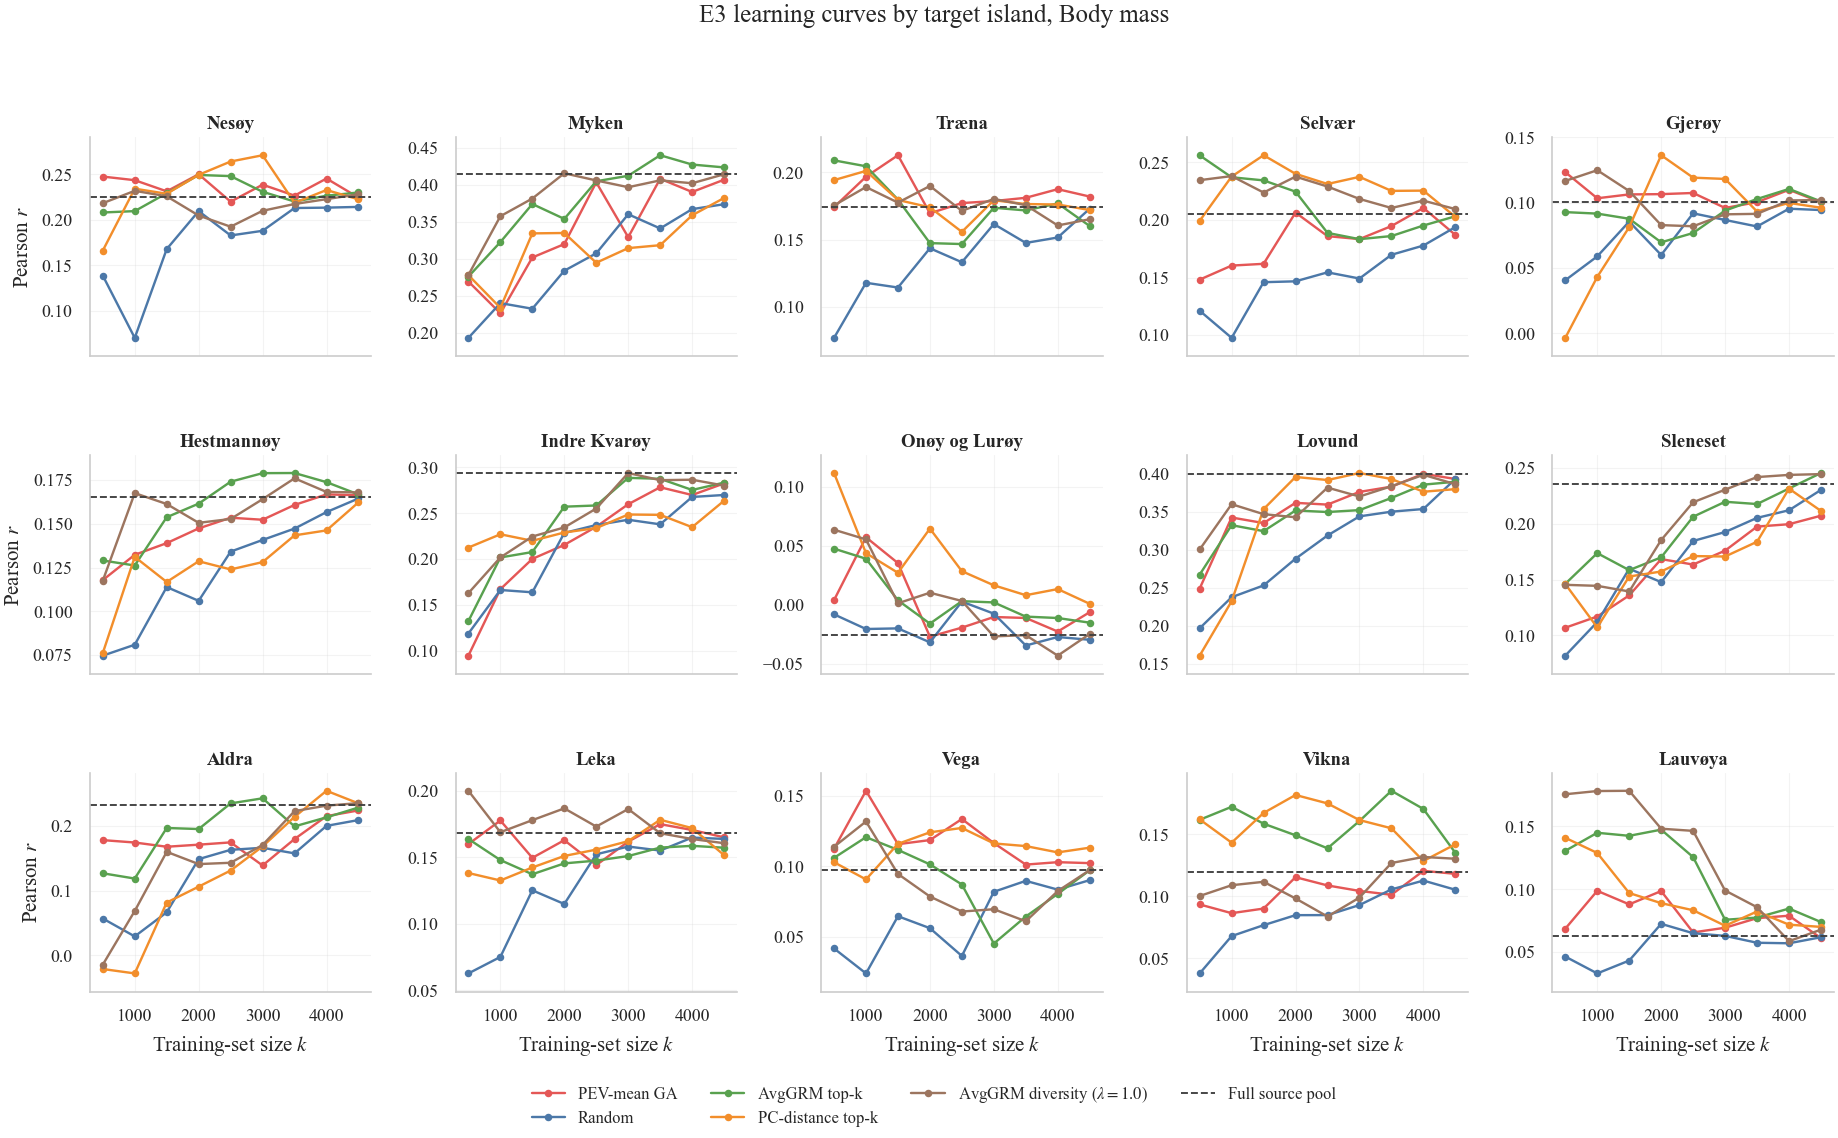

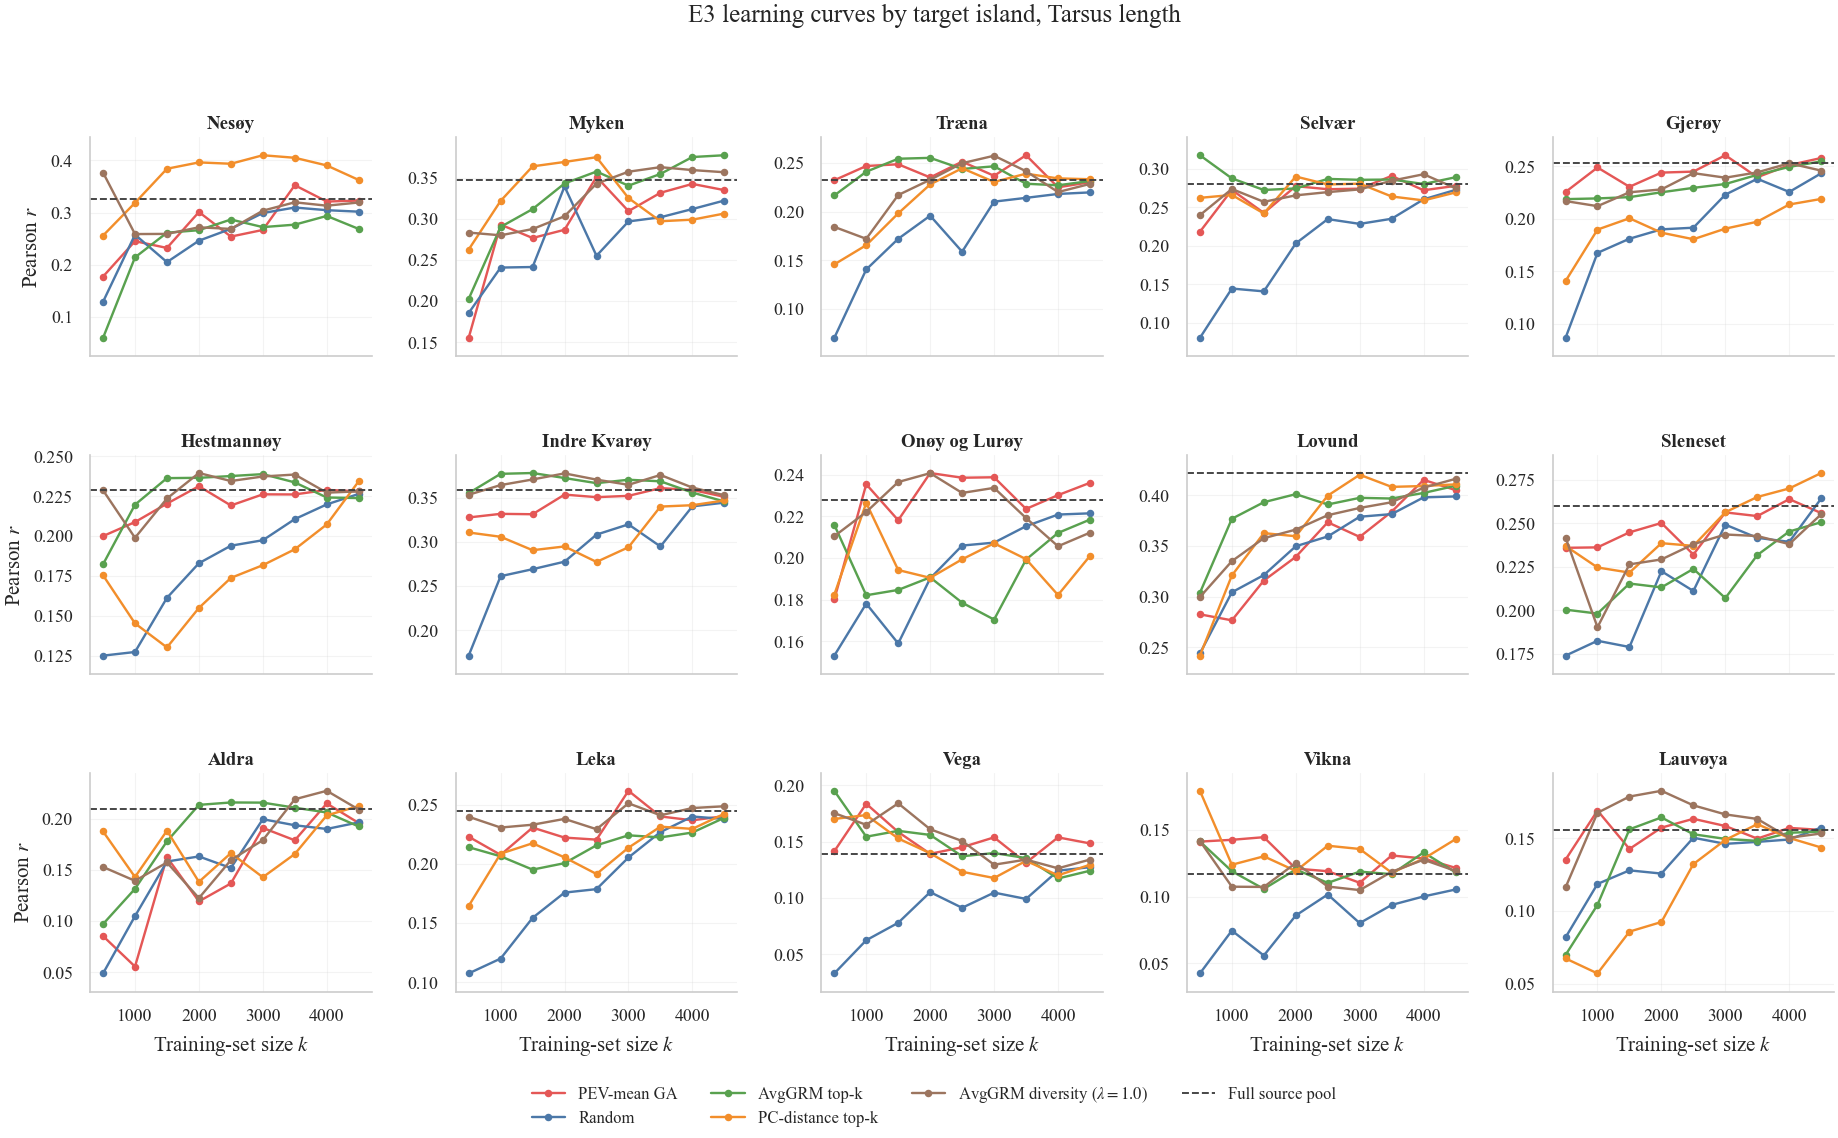

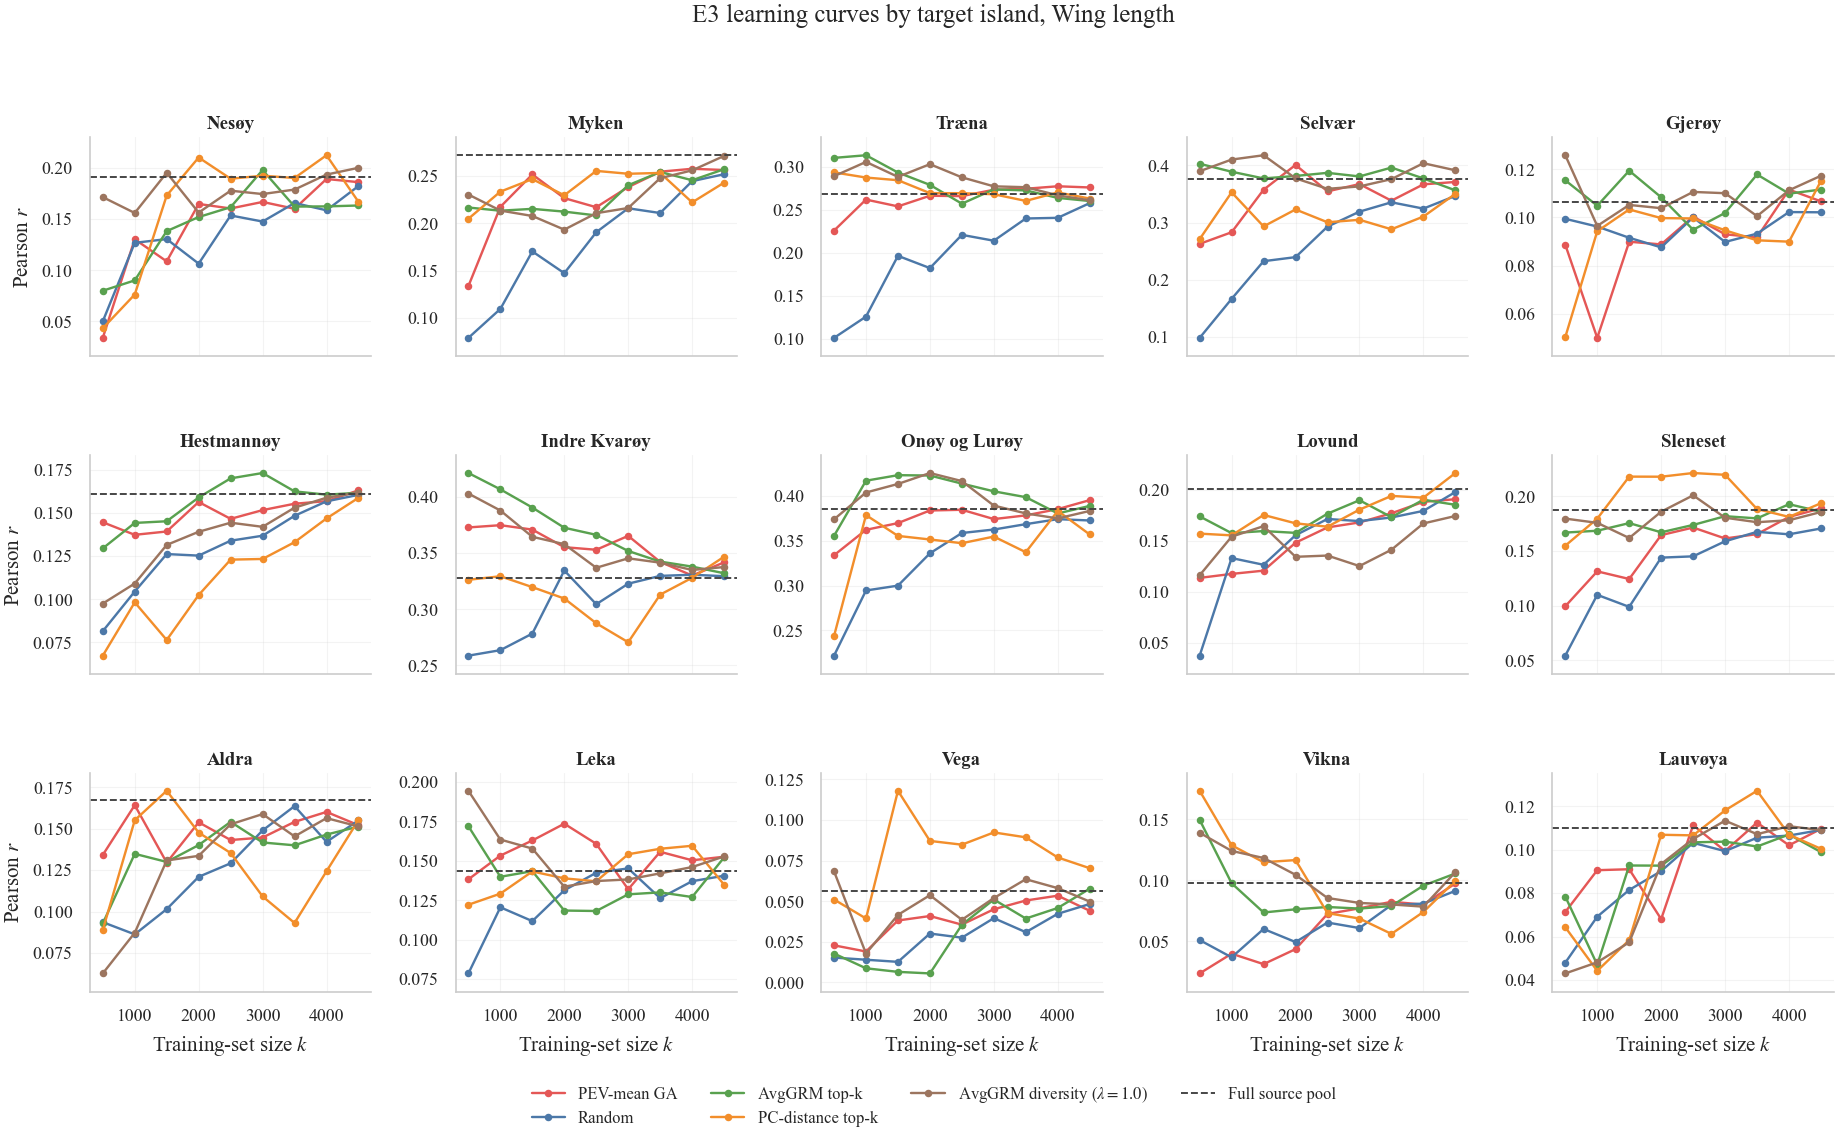

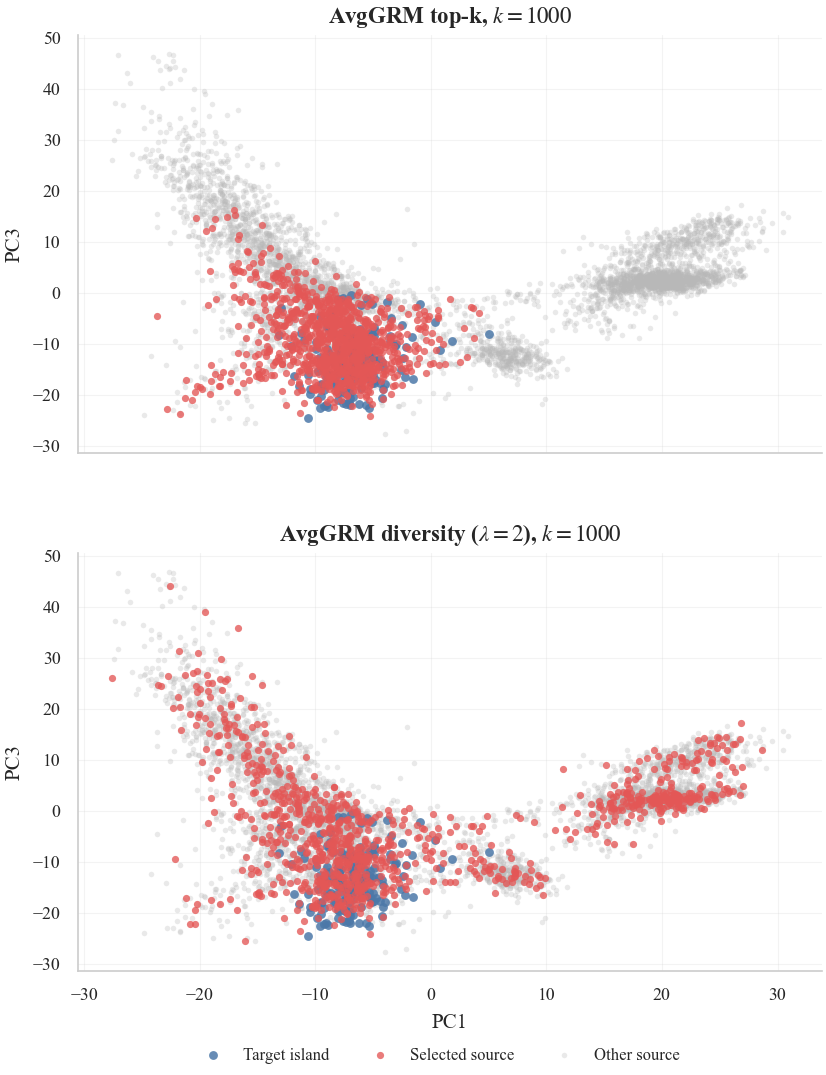

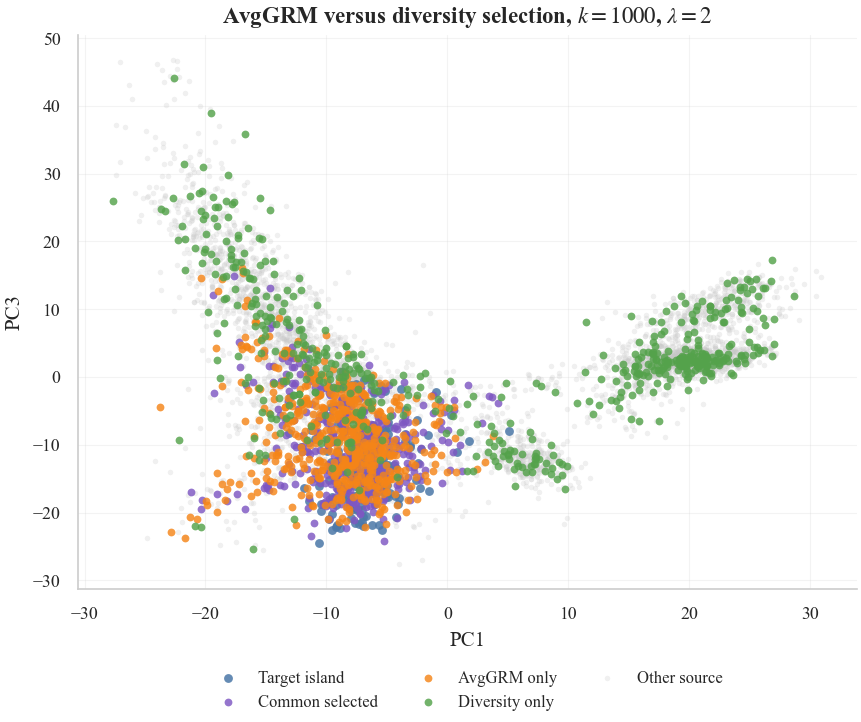

{'main': (WindowsPath('c:/Users/Simen/OneDrive - NTNU/FYSMAT/INDMAT/MASTER/69c525a2d91967a989023aaf/Figures/e3_learning_curves_main.pdf'),
  WindowsPath('c:/Users/Simen/OneDrive - NTNU/FYSMAT/INDMAT/MASTER/69c525a2d91967a989023aaf/Figures/e3_learning_curves_main.png')),
 'diversity': (WindowsPath('c:/Users/Simen/OneDrive - NTNU/FYSMAT/INDMAT/MASTER/69c525a2d91967a989023aaf/Figures/e3_learning_curves_diversity.pdf'),
  WindowsPath('c:/Users/Simen/OneDrive - NTNU/FYSMAT/INDMAT/MASTER/69c525a2d91967a989023aaf/Figures/e3_learning_curves_diversity.png')),
 'by_island': {'body_mass': (WindowsPath('c:/Users/Simen/OneDrive - NTNU/FYSMAT/INDMAT/MASTER/69c525a2d91967a989023aaf/Figures/e3_learning_curves_by_island_main_body_mass.pdf'),
   WindowsPath('c:/Users/Simen/OneDrive - NTNU/FYSMAT/INDMAT/MASTER/69c525a2d91967a989023aaf/Figures/e3_learning_curves_by_island_main_body_mass.png')),
  'thr_tarsus': (WindowsPath('c:/Users/Simen/OneDrive - NTNU/FYSMAT/INDMAT/MASTER/69c525a2d91967a989023aaf/Figur

In [32]:
def plot_e3_learning_curves(
    df,
    output_dir=FIGURES_DIR,
    file_stem="e3_learning_curves",
    trait_order=None,
    method_labels=None,
    full_pool_df=None,
    full_pool_label="Full source pool (PC ridge, tuned)",
    show_zero_line=False,
):
    """One panel per trait: mean Pearson r vs training-set size, GA vs random.

    full_pool_df: optional per-fold DataFrame (same schema as e1_fixed_l10_raw) used
    to draw a horizontal dashed line at the mean across islands for each trait.
    """
    if df is None or df.empty:
        print("No E3 results yet.")
        return {}

    trait_order = list(trait_order or [t for t in TRAIT_LABELS if t in set(df["trait"])])
    trait_order += [t for t in df["trait"].dropna().unique() if t not in trait_order]

    full_pool_means = {}
    if full_pool_df is not None and not full_pool_df.empty:
        full_pool_means = full_pool_df.groupby("trait")["pearson_r"].mean().to_dict()

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    paths = {}

    for trait in trait_order:
        sub = df[df["trait"] == trait].copy()
        if method_labels is not None:
            sub = sub[sub["method_label"].isin(method_labels)].copy()
        if sub.empty:
            continue

        agg = (
            sub.groupby(["method_label", "n_train_size"], as_index=False)
            .agg(
                pearson_r_mean=("pearson_r", "mean"),
                pearson_r_std=("pearson_r", "std"),
                n=("pearson_r", "size"),
            )
        )
        agg["se"] = agg["pearson_r_std"] / np.sqrt(agg["n"])

        fig, ax = plt.subplots(figsize=(6.5, 4.2), constrained_layout=True)

        plot_order = list(method_labels or [])
        plot_order += [label for label in agg["method_label"].dropna().unique() if label not in plot_order]
        for method_label in plot_order:
            grp = agg[agg["method_label"] == method_label]
            if grp.empty:
                continue
            color = E3_METHOD_COLORS.get(method_label, "#888888")
            grp = grp.sort_values("n_train_size")
            ax.plot(
                grp["n_train_size"], grp["pearson_r_mean"],
                marker="o", markersize=4.5, linewidth=1.6,
                color=color, label=method_label,
            )
            ax.fill_between(
                grp["n_train_size"],
                grp["pearson_r_mean"] - grp["se"],
                grp["pearson_r_mean"] + grp["se"],
                alpha=0.18, color=color,
            )

        baseline = full_pool_means.get(trait)
        if baseline is not None and np.isfinite(baseline):
            ax.axhline(
                baseline, color="0.25", linewidth=1.2, linestyle="--",
                label=f"{full_pool_label} (r = {baseline:.3f})",
            )

        if show_zero_line:
            ax.axhline(0, color="0.5", linewidth=0.8, linestyle=":")
        ax.set_xlabel("Training-set size $k$")
        ax.set_ylabel("Pearson $r$ (mean ± SE)")
        ax.set_title(f"E3 learning curves — {TRAIT_LABELS.get(trait, trait)}")
        ax.legend(frameon=False)
        style_axes(ax)

        pdf_path = output_dir / f"{file_stem}_{trait}.pdf"
        png_path = output_dir / f"{file_stem}_{trait}.png"
        pdf_path = save_figure(fig, pdf_path, bbox_inches="tight")
        png_path = save_figure(fig, png_path, bbox_inches="tight")
        paths[trait] = (pdf_path, png_path)
        plt.show()

    return paths


def plot_e3_learning_curves_grid(
    df,
    output_dir=FIGURES_DIR,
    file_stem="e3_learning_curves_grid",
    trait_order=None,
    method_labels=None,
    full_pool_df=None,
    full_pool_label="Full source pool",
    show_se=True,
):
    if df is None or df.empty:
        print("No E3 results yet.")
        return None

    trait_order = list(trait_order or [t for t in TRAIT_LABELS if t in set(df["trait"])])
    trait_order += [t for t in df["trait"].dropna().unique() if t not in trait_order]
    n_traits = len(trait_order)
    if n_traits == 0:
        return None

    full_pool_means = {}
    if full_pool_df is not None and not full_pool_df.empty:
        full_pool_means = full_pool_df.groupby("trait")["pearson_r"].mean().to_dict()

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    fig, axes = plt.subplots(
        1, n_traits,
        figsize=(4.2 * n_traits, 4.1),
        squeeze=False,
    )
    fig.subplots_adjust(bottom=0.28, wspace=0.28)
    axes = axes.ravel()
    handles_by_label = {}

    for ax, trait in zip(axes, trait_order):
        sub = df[df["trait"] == trait].copy()
        if method_labels is not None:
            sub = sub[sub["method_label"].isin(method_labels)].copy()
        if sub.empty:
            ax.set_visible(False)
            continue

        agg = (
            sub.groupby(["method_label", "n_train_size"], as_index=False)
            .agg(
                pearson_r_mean=("pearson_r", "mean"),
                pearson_r_std=("pearson_r", "std"),
                n=("pearson_r", "size"),
            )
        )
        agg["se"] = agg["pearson_r_std"] / np.sqrt(agg["n"])

        plot_order = list(method_labels or [])
        plot_order += [label for label in agg["method_label"].dropna().unique() if label not in plot_order]
        for method_label in plot_order:
            grp = agg[agg["method_label"] == method_label].sort_values("n_train_size")
            if grp.empty:
                continue
            color = E3_METHOD_COLORS.get(method_label, "#888888")
            line = ax.plot(
                grp["n_train_size"], grp["pearson_r_mean"],
                marker="o", markersize=3.8, linewidth=1.5,
                color=color, label=method_label,
            )[0]
            handles_by_label.setdefault(method_label, line)
            if show_se:
                ax.fill_between(
                    grp["n_train_size"],
                    grp["pearson_r_mean"] - grp["se"],
                    grp["pearson_r_mean"] + grp["se"],
                    alpha=0.14, color=color,
                )

        baseline = full_pool_means.get(trait)
        if baseline is not None and np.isfinite(baseline):
            line = ax.axhline(baseline, color="0.25", linewidth=1.1, linestyle="--")
            handles_by_label.setdefault(full_pool_label, line)

        ax.set_xlabel("Training-set size $k$")
        ax.set_title(TRAIT_LABELS.get(trait, trait))
        ax.margins(y=0.08)
        style_axes(ax)

    ylabel = "Pearson $r$ (mean +/- SE)" if show_se else "Pearson $r$ (mean)"
    axes[0].set_ylabel(ylabel)
    labels = [label for label in (method_labels or []) if label in handles_by_label]
    labels += [label for label in handles_by_label if label not in labels]
    fig.legend(
        [handles_by_label[label] for label in labels], labels,
        loc="lower center", bbox_to_anchor=(0.5, 0.02),
        ncol=min(3, max(1, len(labels))), frameon=False,
    )

    pdf_path = output_dir / f"{file_stem}.pdf"
    png_path = output_dir / f"{file_stem}.png"
    pdf_path = save_figure(fig, pdf_path, bbox_inches="tight")
    png_path = save_figure(fig, png_path, bbox_inches="tight")
    plt.show()
    return pdf_path, png_path


def plot_e3_learning_curves_by_island_grid(
    df,
    output_dir=FIGURES_DIR,
    file_stem="e3_learning_curves_by_island",
    trait_order=None,
    method_labels=None,
    full_pool_df=None,
    full_pool_label="Full source pool",
    ncols=5,
    show_se=False,
):
    if df is None or df.empty:
        print("No E3 results yet.")
        return {}
    if "target_island" not in df.columns:
        print("No target_island column found; cannot make island-grid curves.")
        return {}

    trait_order = list(trait_order or [t for t in TRAIT_LABELS if t in set(df["trait"])])
    trait_order += [t for t in df["trait"].dropna().unique() if t not in trait_order]

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    paths = {}
    full_pool_means = {}
    if full_pool_df is not None and not full_pool_df.empty:
        if {"trait", "test_island_code", "pearson_r"}.issubset(full_pool_df.columns):
            full_pool_means = (
                full_pool_df.groupby(["trait", "test_island_code"])["pearson_r"]
                .mean()
                .to_dict()
            )

    for trait in trait_order:
        sub_trait = df[df["trait"] == trait].copy()
        if method_labels is not None:
            sub_trait = sub_trait[sub_trait["method_label"].isin(method_labels)].copy()
        if sub_trait.empty:
            continue

        islands = (
            sub_trait[["target_island", "target_island_name"]]
            .drop_duplicates()
            .sort_values("target_island")
        )
        n_islands = len(islands)
        ncols_eff = min(int(ncols), n_islands)
        nrows = int(np.ceil(n_islands / ncols_eff))
        fig, axes = plt.subplots(
            nrows, ncols_eff,
            figsize=(3.0 * ncols_eff, 2.35 * nrows + 0.65),
            squeeze=False,
            sharex=True,
        )
        fig.subplots_adjust(bottom=0.14, hspace=0.45, wspace=0.30)
        axes_flat = axes.ravel()
        handles_by_label = {}

        for ax, (_, island_row) in zip(axes_flat, islands.iterrows()):
            island_code = island_row["target_island"]
            island_name = island_row["target_island_name"]
            sub = sub_trait[sub_trait["target_island"] == island_code].copy()
            agg = (
                sub.groupby(["method_label", "n_train_size"], as_index=False)
                .agg(
                    pearson_r_mean=("pearson_r", "mean"),
                    pearson_r_std=("pearson_r", "std"),
                    n=("pearson_r", "size"),
                )
            )
            agg["se"] = agg["pearson_r_std"] / np.sqrt(agg["n"])
            plot_order = list(method_labels or [])
            plot_order += [label for label in agg["method_label"].dropna().unique() if label not in plot_order]
            for method_label in plot_order:
                grp = agg[agg["method_label"] == method_label].sort_values("n_train_size")
                if grp.empty:
                    continue
                color = E3_METHOD_COLORS.get(method_label, "#888888")
                line = ax.plot(
                    grp["n_train_size"], grp["pearson_r_mean"],
                    marker="o", markersize=2.6, linewidth=1.15,
                    color=color, label=method_label,
                )[0]
                handles_by_label.setdefault(method_label, line)
                if show_se:
                    ax.fill_between(
                        grp["n_train_size"],
                        grp["pearson_r_mean"] - grp["se"],
                        grp["pearson_r_mean"] + grp["se"],
                        alpha=0.12, color=color,
                    )
            baseline = full_pool_means.get((trait, island_code))
            if baseline is None:
                try:
                    baseline = full_pool_means.get((trait, int(island_code)))
                except (TypeError, ValueError):
                    baseline = None
            if baseline is not None and np.isfinite(baseline):
                line = ax.axhline(baseline, color="0.25", linewidth=0.9, linestyle="--")
                handles_by_label.setdefault(full_pool_label, line)
            ax.set_title(str(island_name), fontsize=9, pad=4)
            ax.margins(y=0.10)
            style_axes(ax)

        for ax in axes_flat[n_islands:]:
            ax.set_visible(False)
        for ax in axes[-1, :]:
            if ax.get_visible():
                ax.set_xlabel("Training-set size $k$")
        for ax in axes[:, 0]:
            ax.set_ylabel("Pearson $r$")

        labels = [label for label in (method_labels or []) if label in handles_by_label]
        labels += [label for label in handles_by_label if label not in labels]
        fig.legend(
            [handles_by_label[label] for label in labels], labels,
            loc="lower center", bbox_to_anchor=(0.5, 0.01),
            ncol=min(4, max(1, len(labels))), frameon=False,
        )
        fig.suptitle(f"E3 learning curves by target island, {TRAIT_LABELS.get(trait, trait)}", y=0.995)

        pdf_path = output_dir / f"{file_stem}_{trait}.pdf"
        png_path = output_dir / f"{file_stem}_{trait}.png"
        pdf_path = save_figure(fig, pdf_path, bbox_inches="tight")
        png_path = save_figure(fig, png_path, bbox_inches="tight")
        plt.show()
        paths[trait] = (pdf_path, png_path)

    return paths


def _load_e4_selection_problem(trait="body_mass"):
    import json as _json
    import sys

    if str(REPO_ROOT) not in sys.path:
        sys.path.insert(0, str(REPO_ROOT))
    from src.data import load_data
    from src.cv_utils import island_label

    cfg_path = REPO_ROOT / "config" / "final_e4_similarity_pc_ridge_config.json"
    with cfg_path.open("r", encoding="utf-8") as fh:
        cfg = _json.load(fh)
    spec = next(item for item in cfg["traits"] if item["name"] == trait)
    paths = dict(cfg.get("paths", {}))
    paths["npz"] = spec["npz"]
    for key in ("npz", "npz_path", "grm_rds", "snp_feather", "phenotype_csv"):
        if key in paths and paths[key] is not None:
            path = Path(paths[key])
            if not path.is_absolute():
                paths[key] = str(REPO_ROOT / path)

    X, y, ids, GRM_df, locality, code_to_label, y_eval = load_data(
        paths=paths,
        target_column=spec.get("target_column", cfg.get("target_column", "y_adjusted")),
        standardize_features=bool(spec.get("standardize_features", cfg.get("standardize_features", False))),
        return_locality=True,
        min_count=int(spec.get("min_count", cfg.get("min_count", 20))),
        return_eval=True,
        eval_target_column=spec.get("eval_target_column", cfg.get("eval_target_column", "y_mean")),
    )
    ids = ids.astype(str)
    locality = locality.astype(int)
    included = cfg.get("included_islands", None)
    if included is not None:
        keep_codes = [int(x) for x in included]
        keep = np.isin(locality, keep_codes)
        X = X[keep]
        y = y[keep]
        y_eval = y_eval[keep]
        ids = ids[keep]
        locality = locality[keep]
        GRM_df = GRM_df.loc[ids, ids]
    return X, ids, GRM_df, locality, code_to_label, island_label


def reconstruct_e4_selection_pca_df(
    trait="body_mass",
    target_island_name="Sleneset",
    k=1000,
    lambda_div=2.0,
):
    import sys
    from sklearn.decomposition import PCA

    if str(REPO_ROOT) not in sys.path:
        sys.path.insert(0, str(REPO_ROOT))
    from src.avggrm_weighting import avg_grm_train_to_target, greedy_avggrm_diversity_order

    X, ids, GRM_df, locality, code_to_label, island_label = _load_e4_selection_problem(trait=trait)
    target_code = next(
        code for code in sorted(np.unique(locality))
        if island_label(int(code), code_to_label).lower() == target_island_name.lower()
    )
    target_idx = np.flatnonzero(locality == int(target_code)).astype(np.int64)
    source_idx = np.flatnonzero(locality != int(target_code)).astype(np.int64)
    k_eff = int(min(int(k), source_idx.size))

    grm = GRM_df.to_numpy(dtype=np.float64)
    avg_grm = avg_grm_train_to_target(grm, source_idx, target_idx)
    avg_order = np.argsort(-avg_grm, kind="mergesort")[:k_eff]
    div_order = greedy_avggrm_diversity_order(
        avg_grm_to_target=avg_grm,
        train_train_grm=grm[np.ix_(source_idx, source_idx)],
        lambda_div=float(lambda_div),
        max_size=k_eff,
        include_diagonal=True,
    )["order"][:k_eff]

    scores = PCA(n_components=3, svd_solver="randomized", random_state=14).fit_transform(X).astype(float)
    base = pd.DataFrame(
        {
            "ringnumber": ids,
            "locality": locality,
            "island_name": [island_label(int(code), code_to_label) for code in locality],
            "PC1": scores[:, 0],
            "PC2": scores[:, 1],
            "PC3": scores[:, 2],
        }
    )

    frames = []
    selected_by_method = {
        "AvgGRM top-k": set(ids[source_idx[avg_order]]),
        fr"AvgGRM diversity ($\lambda={lambda_div:g}$)": set(ids[source_idx[div_order]]),
    }
    for method, selected_ids in selected_by_method.items():
        tmp = base.copy()
        tmp["method"] = method
        tmp["status"] = "Other source"
        tmp.loc[tmp["locality"] == int(target_code), "status"] = "Target island"
        tmp.loc[tmp["ringnumber"].isin(selected_ids), "status"] = "Selected source"
        frames.append(tmp)
    return pd.concat(frames, ignore_index=True)


def plot_e4_sleneset_selection_pca(
    trait="body_mass",
    target_island_name="Sleneset",
    k=1000,
    lambda_div=2.0,
    output_dir=FIGURES_DIR,
    file_stem="e4_sleneset_selection_pc1_pc3_k1000",
):
    plot_df = reconstruct_e4_selection_pca_df(
        trait=trait,
        target_island_name=target_island_name,
        k=k,
        lambda_div=lambda_div,
    )
    methods = plot_df["method"].drop_duplicates().tolist()
    colors = {
        "Other source": "#B8B8B8",
        "Target island": "#4C78A8",
        "Selected source": "#E45756",
    }
    sizes = {"Other source": 7, "Target island": 18, "Selected source": 12}
    alphas = {"Other source": 0.30, "Target island": 0.85, "Selected source": 0.78}

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    fig, axes = plt.subplots(2, 1, figsize=(6.4, 8.0), sharex=True, sharey=True)
    handles_by_label = {}
    for ax, method in zip(axes, methods):
        sub = plot_df[plot_df["method"] == method]
        for status in ["Other source", "Target island", "Selected source"]:
            grp = sub[sub["status"] == status]
            handle = ax.scatter(
                grp["PC1"], grp["PC3"],
                s=sizes[status], c=colors[status], alpha=alphas[status],
                linewidths=0, label=status,
            )
            handles_by_label.setdefault(status, handle)
        ax.set_title(f"{method}, $k={k}$")
        ax.set_ylabel("PC3")
        style_axes(ax)
    axes[-1].set_xlabel("PC1")
    fig.legend(
        [handles_by_label[label] for label in ["Target island", "Selected source", "Other source"]],
        ["Target island", "Selected source", "Other source"],
        loc="lower center", bbox_to_anchor=(0.5, 0.01), ncol=3, frameon=False,
    )
    fig.subplots_adjust(bottom=0.10, hspace=0.24)

    pdf_path = output_dir / f"{file_stem}.pdf"
    png_path = output_dir / f"{file_stem}.png"
    pdf_path = save_figure(fig, pdf_path, bbox_inches="tight")
    png_path = save_figure(fig, png_path, bbox_inches="tight")
    plt.show()
    return pdf_path, png_path


def plot_e4_sleneset_selection_overlap_pca(
    trait="body_mass",
    target_island_name="Sleneset",
    k=1000,
    lambda_div=2.0,
    output_dir=FIGURES_DIR,
    file_stem="e4_sleneset_selection_overlap_pc1_pc3_k1000",
):
    plot_df = reconstruct_e4_selection_pca_df(
        trait=trait,
        target_island_name=target_island_name,
        k=k,
        lambda_div=lambda_div,
    )
    avg_label = "AvgGRM top-k"
    div_label = fr"AvgGRM diversity ($\lambda={lambda_div:g}$)"
    base = plot_df[plot_df["method"] == avg_label].copy()
    avg_selected = set(base.loc[base["status"] == "Selected source", "ringnumber"])
    div_selected = set(
        plot_df.loc[
            (plot_df["method"] == div_label) & (plot_df["status"] == "Selected source"),
            "ringnumber",
        ]
    )
    common_selected = avg_selected & div_selected
    avg_only = avg_selected - div_selected
    div_only = div_selected - avg_selected

    base["selection_group"] = "Other source"
    base.loc[base["locality"] == base.loc[base["status"] == "Target island", "locality"].iloc[0], "selection_group"] = "Target island"
    base.loc[base["ringnumber"].isin(common_selected), "selection_group"] = "Common selected"
    base.loc[base["ringnumber"].isin(avg_only), "selection_group"] = "AvgGRM only"
    base.loc[base["ringnumber"].isin(div_only), "selection_group"] = "Diversity only"

    colors = {
        "Other source": "#C7C7C7",
        "Target island": "#4C78A8",
        "Common selected": "#7E57C2",
        "AvgGRM only": "#F58518",
        "Diversity only": "#54A24B",
    }
    sizes = {
        "Other source": 7,
        "Target island": 18,
        "Common selected": 14,
        "AvgGRM only": 14,
        "Diversity only": 14,
    }
    alphas = {
        "Other source": 0.26,
        "Target island": 0.86,
        "Common selected": 0.82,
        "AvgGRM only": 0.82,
        "Diversity only": 0.82,
    }
    order = ["Other source", "Target island", "Common selected", "AvgGRM only", "Diversity only"]

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    fig, ax = plt.subplots(figsize=(6.7, 4.8))
    handles_by_label = {}
    for group in order:
        grp = base[base["selection_group"] == group]
        handle = ax.scatter(
            grp["PC1"], grp["PC3"],
            s=sizes[group], c=colors[group], alpha=alphas[group],
            linewidths=0, label=group,
        )
        handles_by_label[group] = handle
    ax.set_title(fr"AvgGRM versus diversity selection, $k={k}$, $\lambda={lambda_div:g}$")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC3")
    style_axes(ax)
    legend_order = ["Target island", "Common selected", "AvgGRM only", "Diversity only", "Other source"]
    ax.legend(
        [handles_by_label[label] for label in legend_order], legend_order,
        loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3, frameon=False,
    )

    pdf_path = output_dir / f"{file_stem}.pdf"
    png_path = output_dir / f"{file_stem}.png"
    pdf_path = save_figure(fig, pdf_path, bbox_inches="tight")
    png_path = save_figure(fig, png_path, bbox_inches="tight")
    plt.show()
    return pdf_path, png_path


E3_DIVERSITY_LABELS = [
    r"AvgGRM diversity ($\lambda=0.25$)",
    r"AvgGRM diversity ($\lambda=0.5$)",
    r"AvgGRM diversity ($\lambda=1.0$)",
    r"AvgGRM diversity ($\lambda=2.0$)",
]
E3_MAIN_BASE_LABELS = [
    "PEV-mean GA",
    "Random",
    "AvgGRM top-k",
    "PC-distance top-k",
]


def choose_best_e3_diversity_label(df):
    diversity = df[df["method_label"].isin(E3_DIVERSITY_LABELS)].copy()
    if diversity.empty:
        return None, pd.Series(dtype=float)
    means = diversity.groupby("method_label")["pearson_r"].mean().sort_values(ascending=False)
    return means.index[0], means


best_diversity_label, e3_diversity_means = choose_best_e3_diversity_label(e3_raw)
e3_main_labels = E3_MAIN_BASE_LABELS + ([best_diversity_label] if best_diversity_label else [])
print(f"Best diversity curve for main E3 figure: {best_diversity_label}")
display(e3_diversity_means)

e3_main_figure_paths = plot_e3_learning_curves_grid(
    e3_raw,
    file_stem="e3_learning_curves_main",
    method_labels=e3_main_labels,
    full_pool_df=e1_fixed_l10_raw,
)
e3_diversity_figure_paths = plot_e3_learning_curves_grid(
    e3_raw,
    file_stem="e3_learning_curves_diversity",
    method_labels=E3_DIVERSITY_LABELS,
    show_se=False,
)
e3_by_island_figure_paths = plot_e3_learning_curves_by_island_grid(
    e3_raw,
    file_stem="e3_learning_curves_by_island_main",
    method_labels=e3_main_labels,
    full_pool_df=e1_fixed_l10_raw,
    show_se=False,
)
e4_sleneset_selection_path = plot_e4_sleneset_selection_pca(
    trait="body_mass",
    target_island_name="Sleneset",
    k=1000,
    lambda_div=2.0,
)
e4_sleneset_selection_overlap_path = plot_e4_sleneset_selection_overlap_pca(
    trait="body_mass",
    target_island_name="Sleneset",
    k=1000,
    lambda_div=2.0,
)
e3_figure_paths = {
    "main": e3_main_figure_paths,
    "diversity": e3_diversity_figure_paths,
    "by_island": e3_by_island_figure_paths,
    "sleneset_selection": e4_sleneset_selection_path,
    "sleneset_selection_overlap": e4_sleneset_selection_overlap_path,
}
e3_figure_paths


### E5: Island-level Data Shapley (PC ridge)

Figures for the final island-level Shapley experiment. The random baseline is the native E5 baseline, evaluated on the same target splits and at the same cumulative sample sizes as the Shapley add-curves.

#### E5 setup and figure generation

In [39]:
import importlib.util
from IPython.display import Image, display

e5_plot_path = REPO_ROOT / "scripts" / "plot_e5_shapley_thesis_figures.py"
spec = importlib.util.spec_from_file_location("e5_shapley_thesis_figures", e5_plot_path)
e5_shapley_thesis_figures = importlib.util.module_from_spec(spec)
spec.loader.exec_module(e5_shapley_thesis_figures)

e5_figure_paths = e5_shapley_thesis_figures.make_e5_shapley_figures(
    repo_root=REPO_ROOT,
    output_dir=FIGURES_DIR,
    e5_root=FINAL_RESULTS_DIR / "e5_shapley_islands_pc_ridge",
    random_fallback_root=FINAL_RESULTS_DIR / "e3_random_pc_ridge",
)
e5_figure_paths


{'summary': (630, 12), 'repeats': (6300, 11), 'add': (25200, 11), 'metadata': (450, 16), 'rank': (315000, 9), 'random_baseline': (18900, 11)}
Loaded 18900 native E5 random-baseline rows


{'heatmaps': (WindowsPath('c:/Users/Simen/OneDrive - NTNU/FYSMAT/INDMAT/MASTER/69c525a2d91967a989023aaf/Figures/e5_shapley_phi_heatmaps.pdf'),
  WindowsPath('c:/Users/Simen/OneDrive - NTNU/FYSMAT/INDMAT/MASTER/69c525a2d91967a989023aaf/Figures/e5_shapley_phi_heatmaps.png')),
 'add_curves': (WindowsPath('c:/Users/Simen/OneDrive - NTNU/FYSMAT/INDMAT/MASTER/69c525a2d91967a989023aaf/Figures/e5_shapley_add_curves.pdf'),
  WindowsPath('c:/Users/Simen/OneDrive - NTNU/FYSMAT/INDMAT/MASTER/69c525a2d91967a989023aaf/Figures/e5_shapley_add_curves.png'),
  'native_e5'),
 'subset_rules': (WindowsPath('c:/Users/Simen/OneDrive - NTNU/FYSMAT/INDMAT/MASTER/69c525a2d91967a989023aaf/Figures/e5_shapley_subset_rules.pdf'),
  WindowsPath('c:/Users/Simen/OneDrive - NTNU/FYSMAT/INDMAT/MASTER/69c525a2d91967a989023aaf/Figures/e5_shapley_subset_rules.png')),
 'discussion_worked': (WindowsPath('c:/Users/Simen/OneDrive - NTNU/FYSMAT/INDMAT/MASTER/69c525a2d91967a989023aaf/Figures/e5_shapley_discussion_worked.pdf'),
 

#### Main figure: source-target Shapley heatmaps

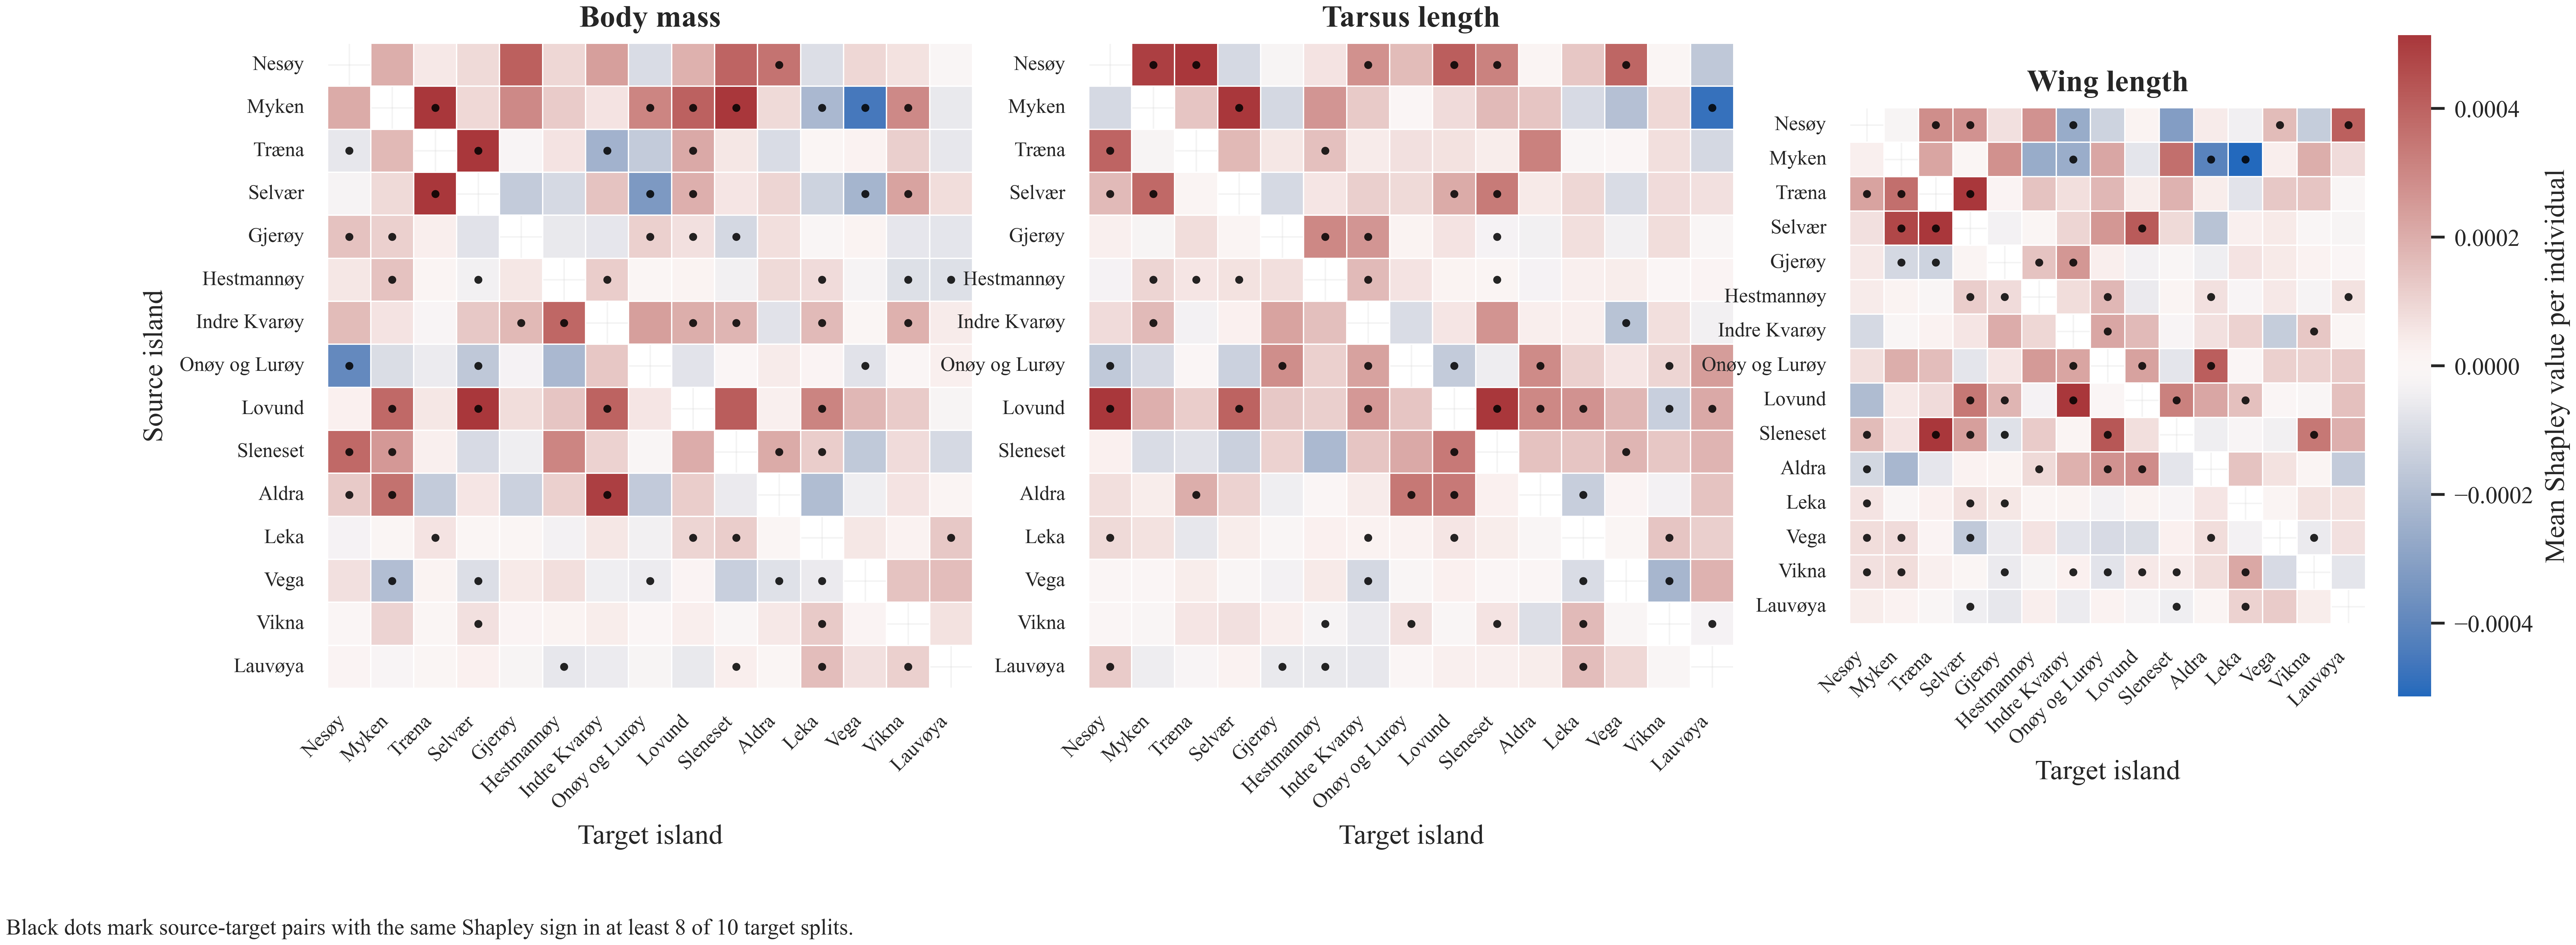

In [40]:
display(Image(filename=str(e5_figure_paths["heatmaps"][1])))


#### Main figure: add-curves and positive-Shapley rule

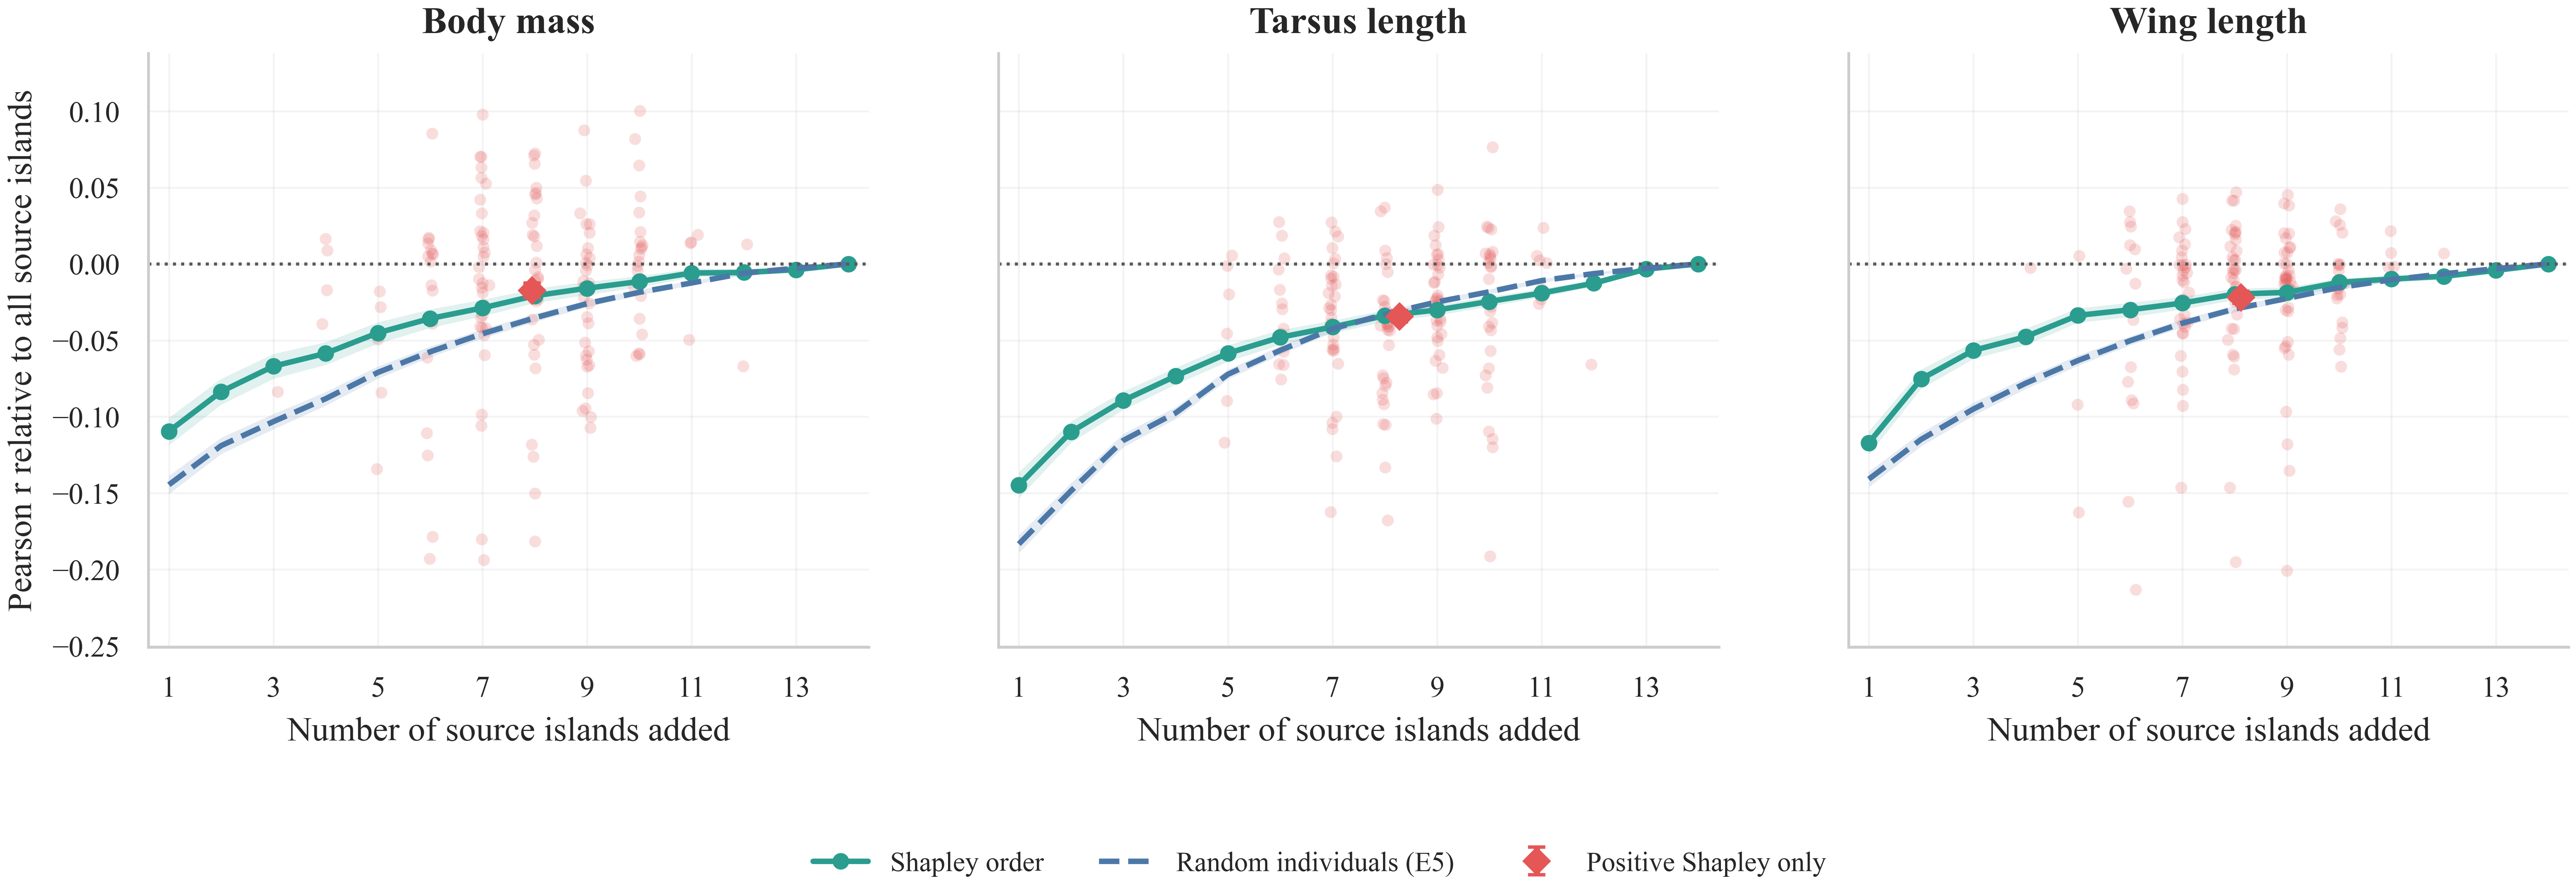

In [41]:
display(Image(filename=str(e5_figure_paths["add_curves"][1])))


#### Discussion figure: what worked

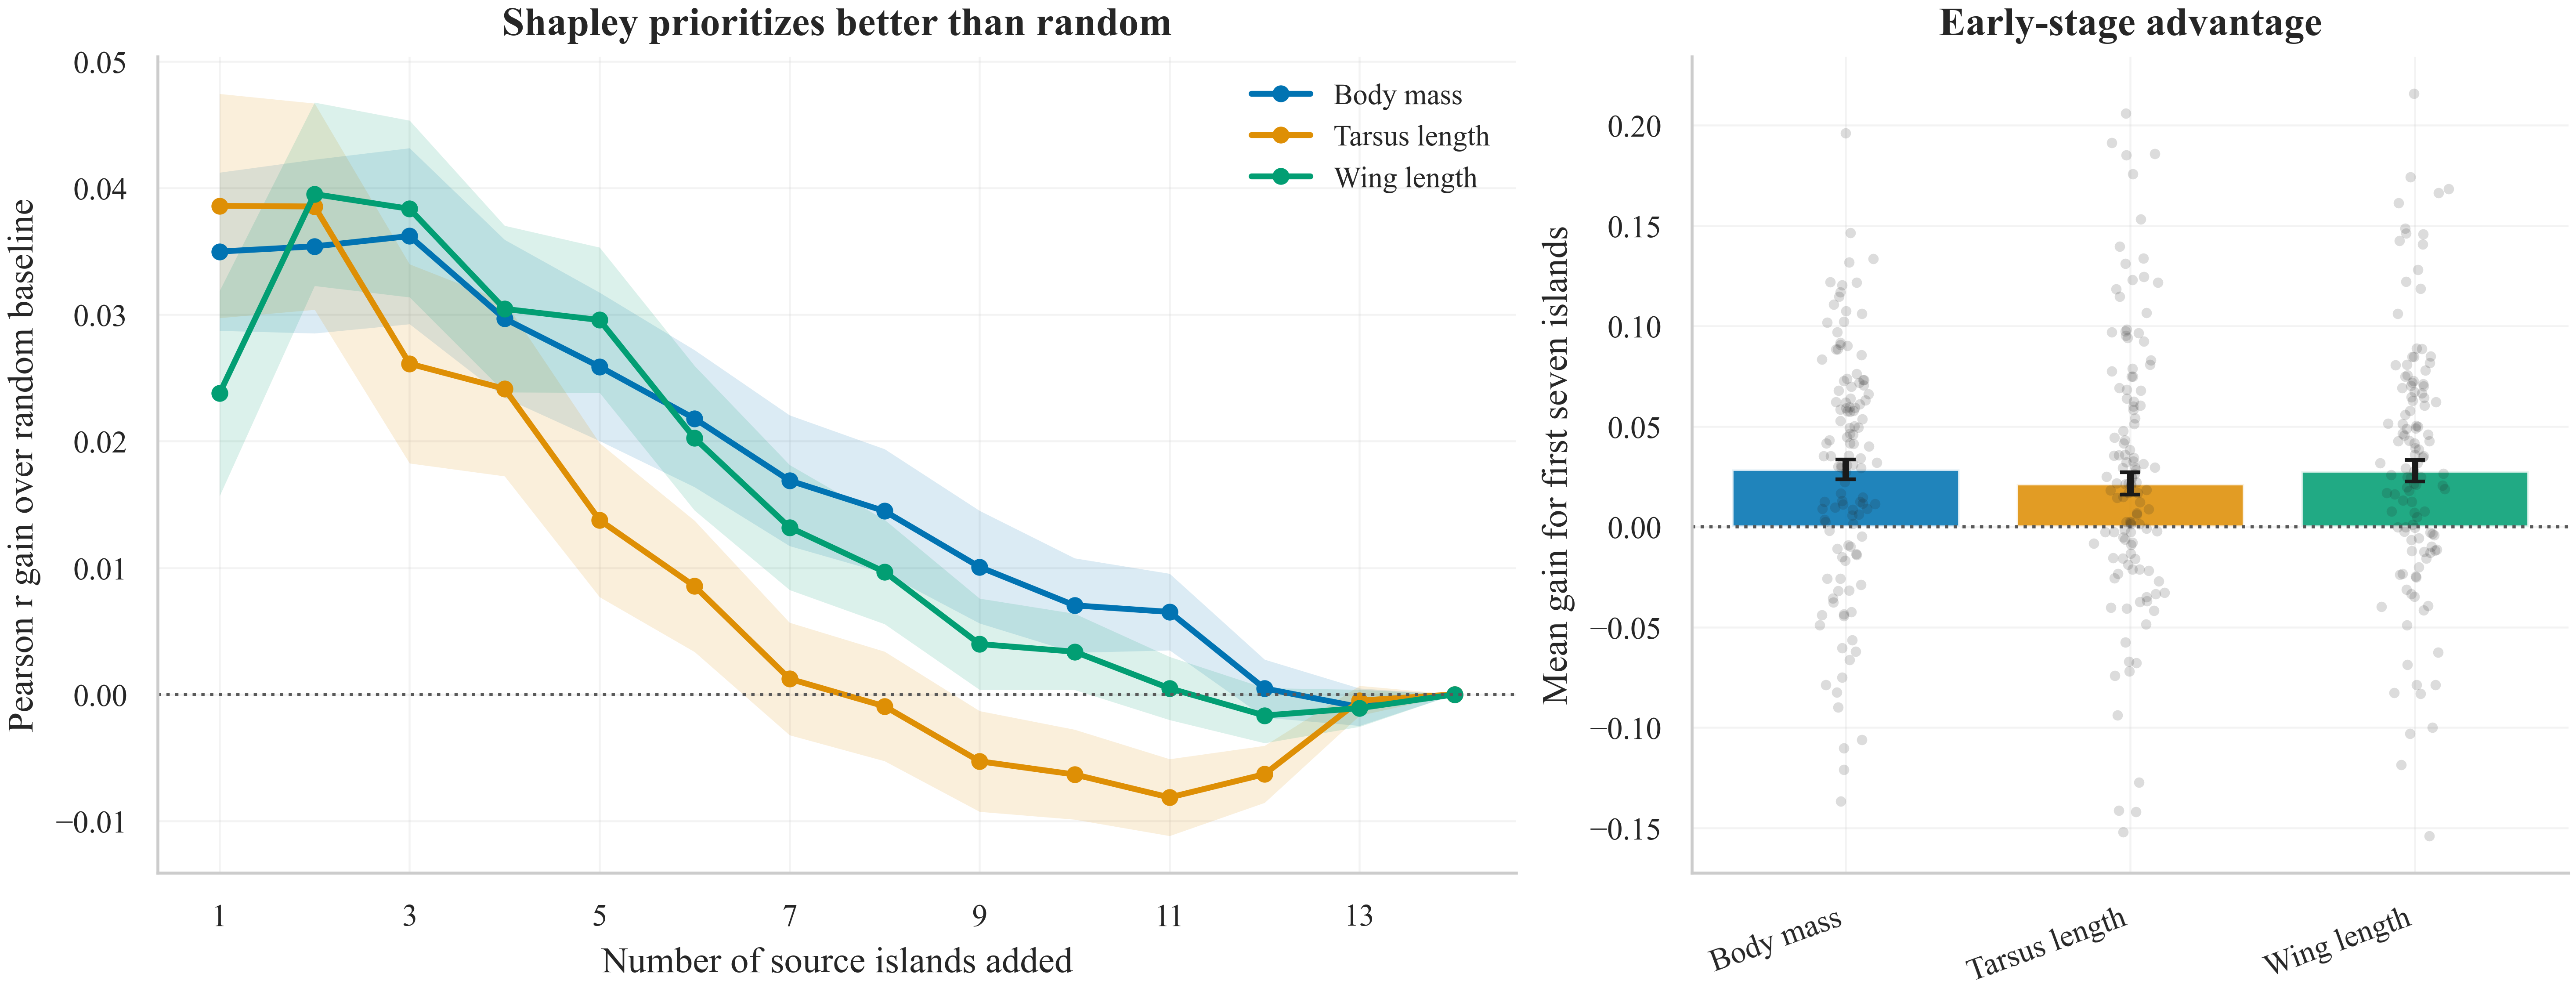

In [42]:
display(Image(filename=str(e5_figure_paths["discussion_worked"][1])))


#### Discussion figure: validation-set instability

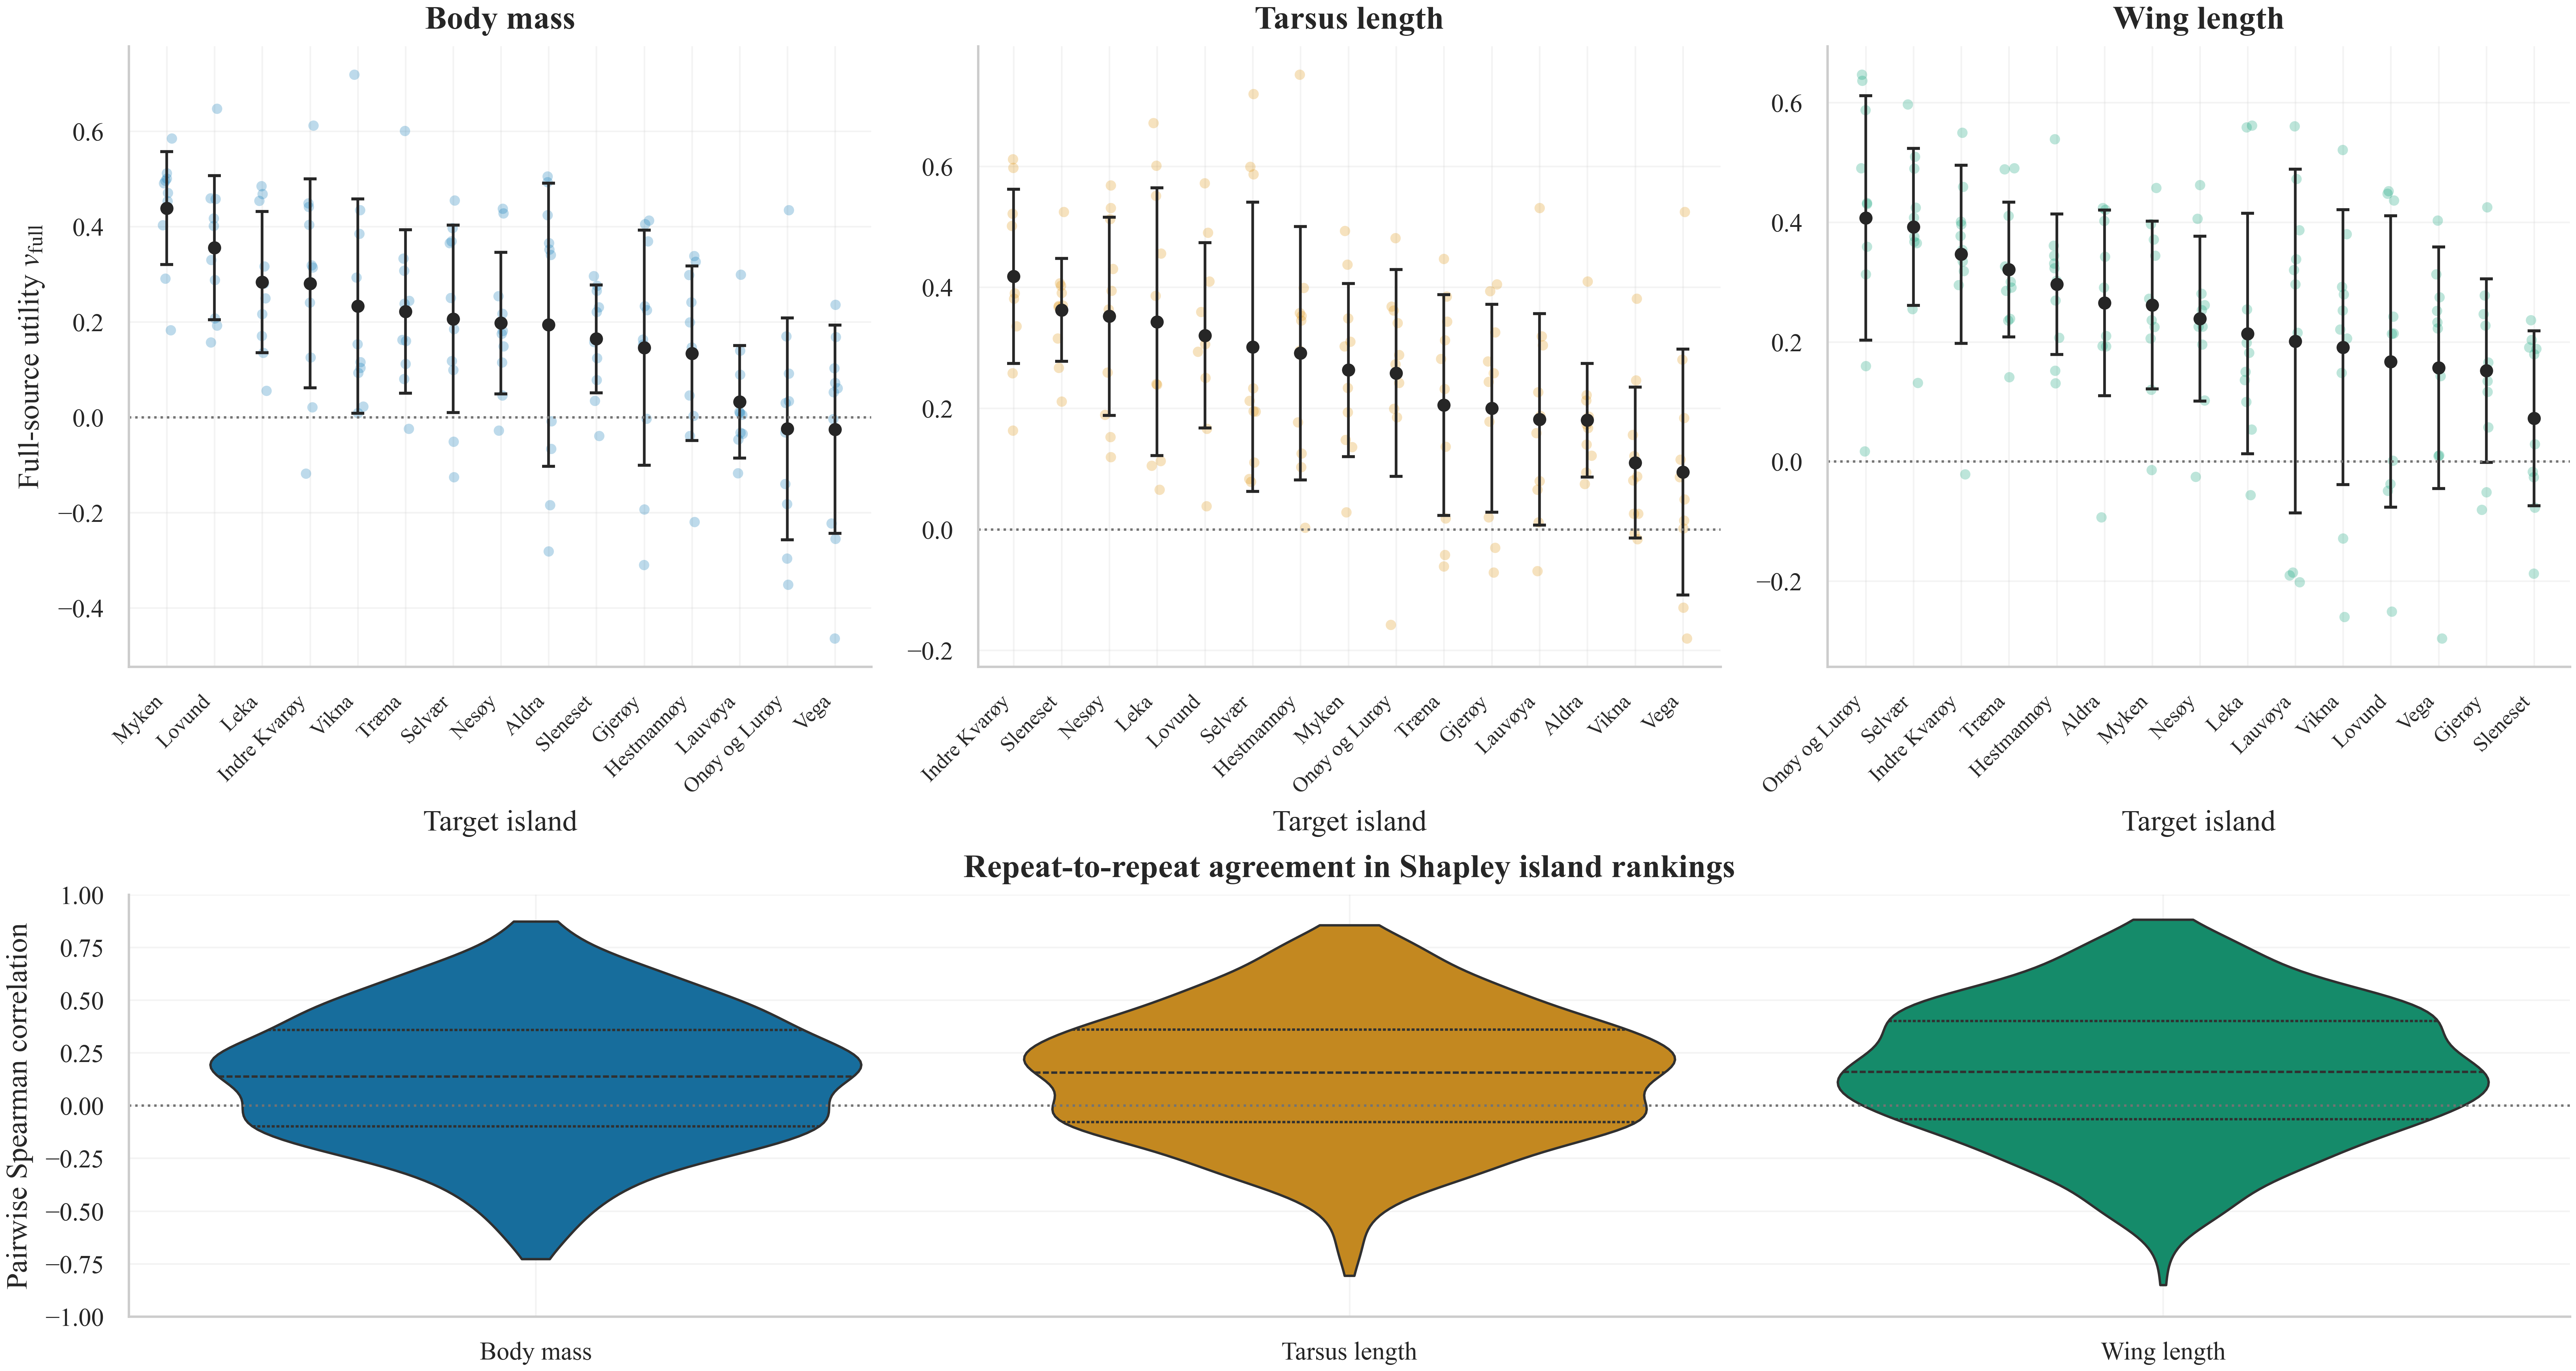

In [43]:
display(Image(filename=str(e5_figure_paths["validation_instability"][1])))


#### Compact rule comparison

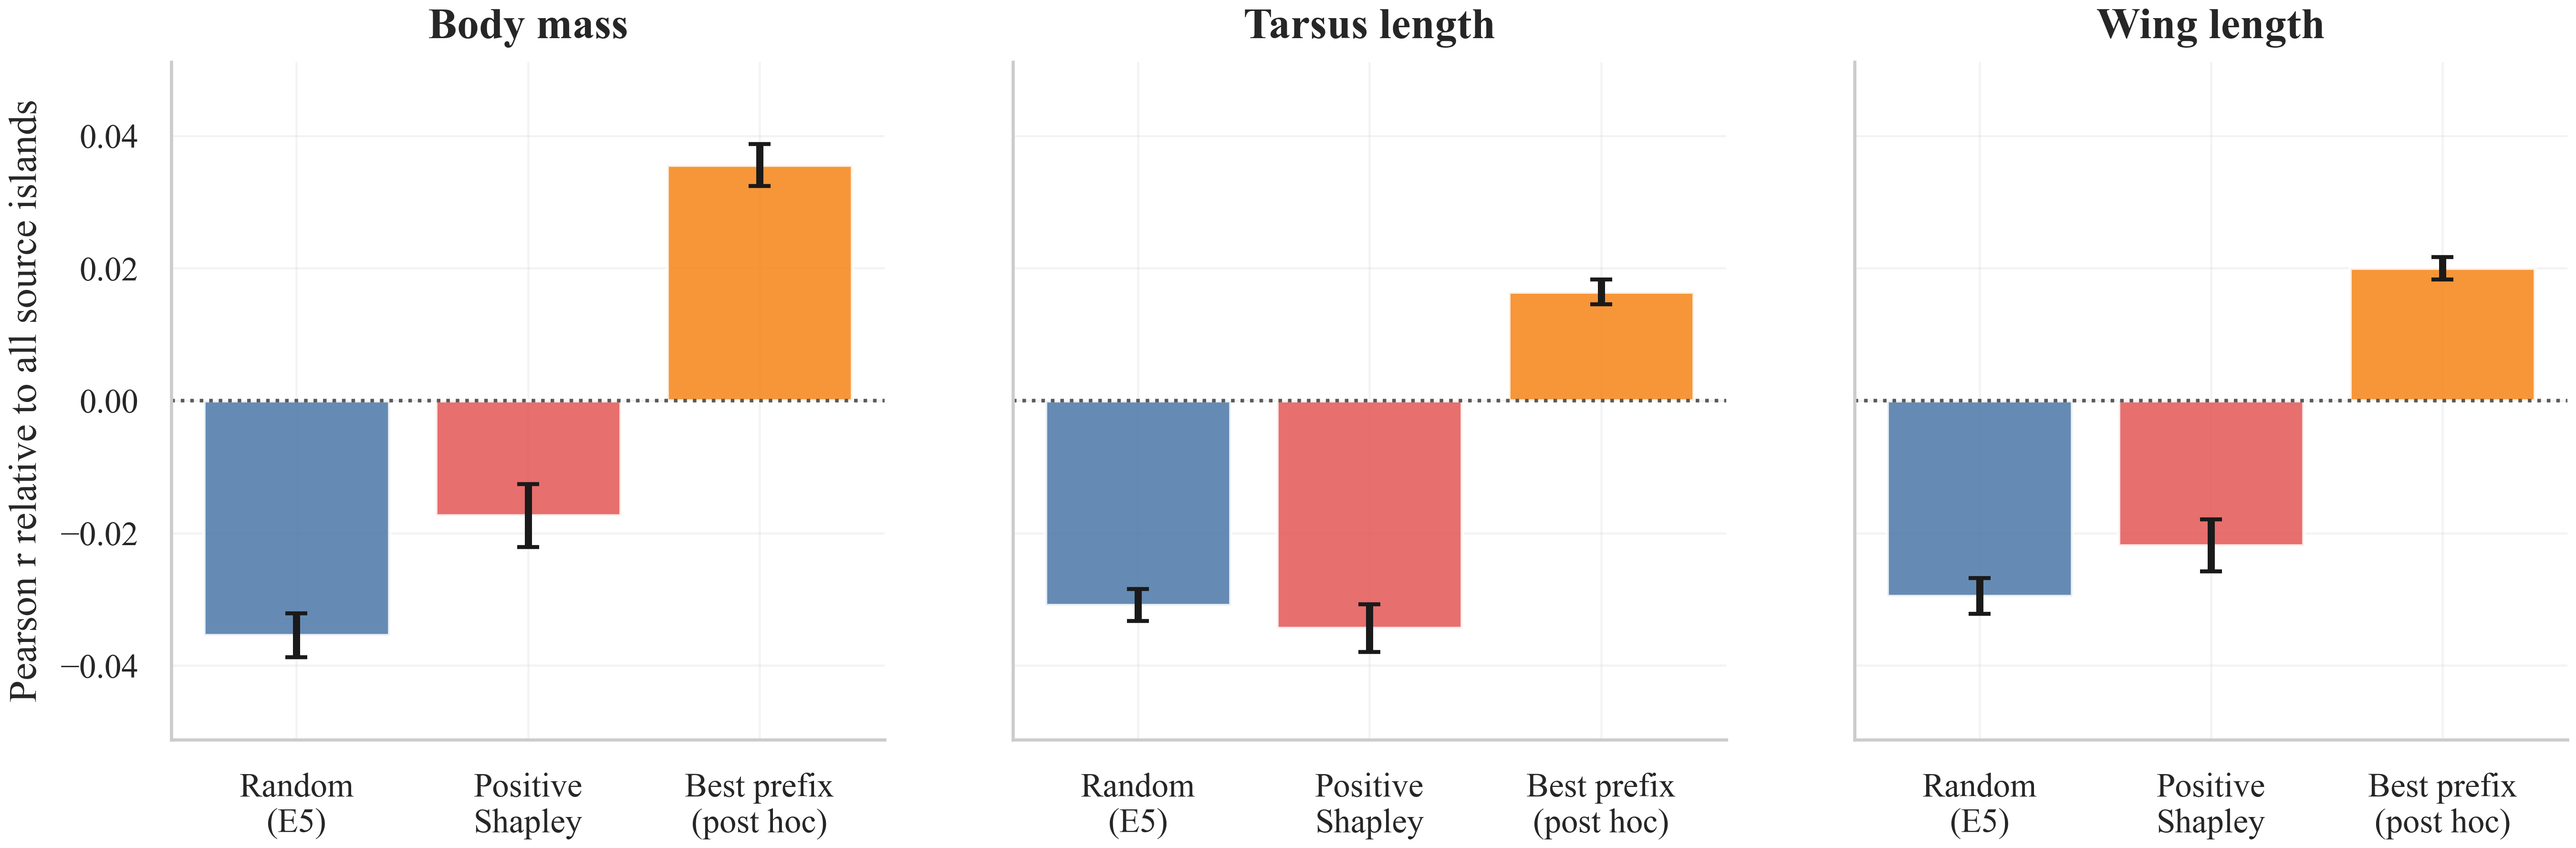

In [44]:
display(Image(filename=str(e5_figure_paths["subset_rules"][1])))


#### Appendix diagnostics: TMC rank convergence

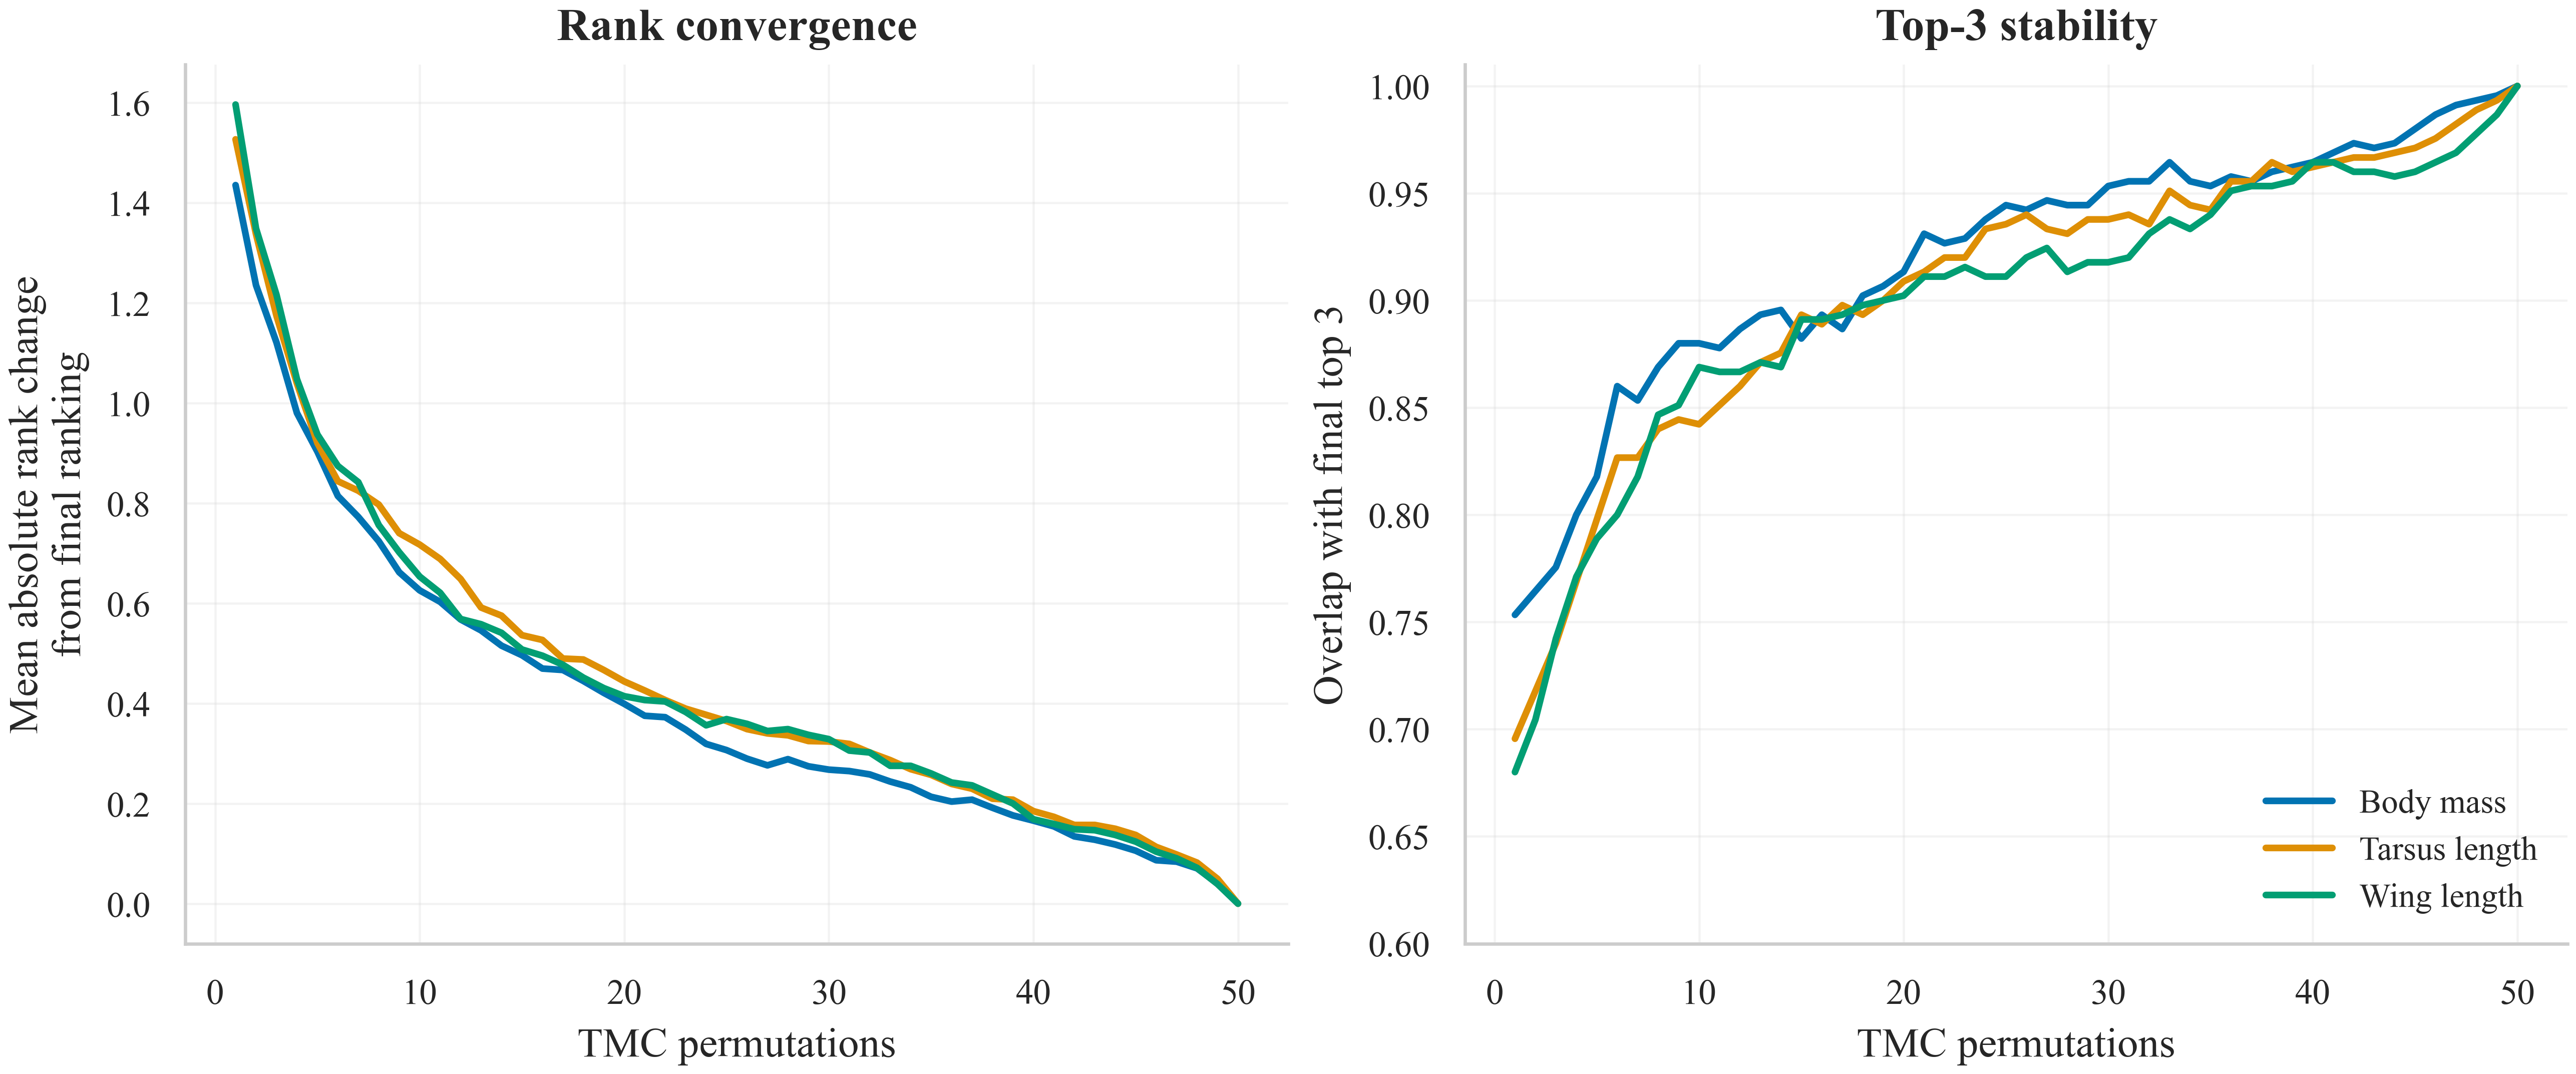

In [45]:
display(Image(filename=str(e5_figure_paths["rank_convergence"][1])))


#### Appendix diagnostics: intermediate running rankings

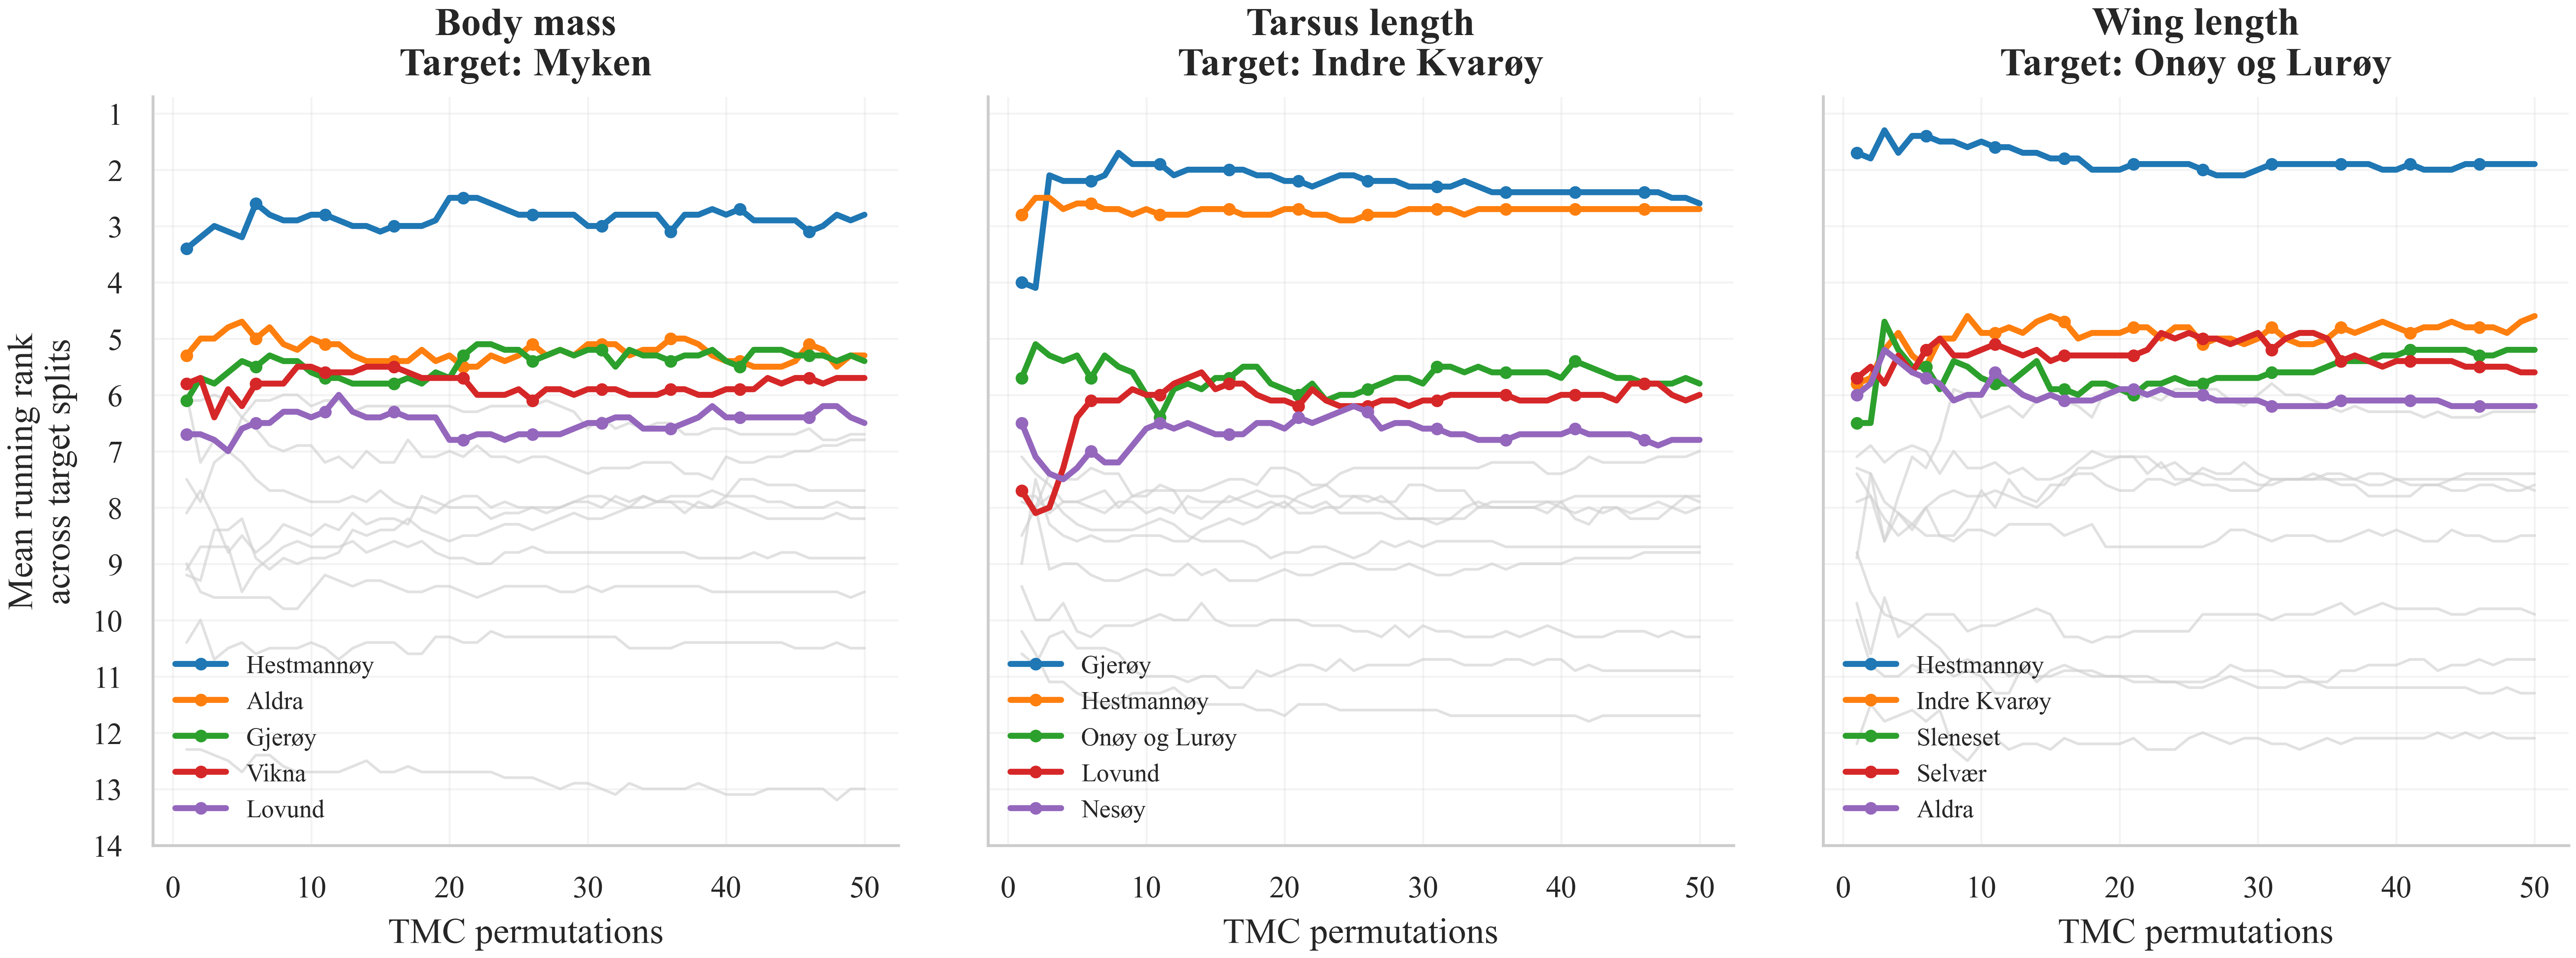

In [46]:
display(Image(filename=str(e5_figure_paths["intermediate_rankings"][1])))
